<a href="https://colab.research.google.com/github/hasmalee/aeropinn/blob/main/aeropinn-x.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Making the Most of your Colab Subscription



# Google Colab is available in VS Code!
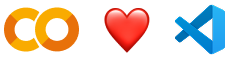

Try the new [Google Colab extension](https://marketplace.visualstudio.com/items?itemName=Google.colab) for Visual Studio Code. You can get up and running in just a few clicks:

*  In VS Code, open the ***Extensions*** view and search for 'Google Colab' to install.
*  Open the kernel selector by creating or opening any `.ipynb` notebook file in your local workspace and either running a cell or clicking the ***Select Kernel*** button in the top right.
*  Click ***Colab*** and then select your desired runtime, sign in with your Google account, and you're all set!

See more details in our [announcement blog here](https://developers.googleblog.com/google-colab-is-coming-to-vs-code).

In [4]:
!pip install -r requirements.txt


In [5]:
import os
import shutil
import sys
from importlib import reload

# find candidate parsec_fit.py files
matches = []
for root, dirs, files in os.walk("/content"):
    if "parsec_fit.py" in files:
        matches.append(os.path.join(root, "parsec_fit.py"))

print("Found parsec_fit.py files:")
for m in matches:
    print(" ", m)

if not matches:
    raise FileNotFoundError("No parsec_fit.py found under /content. Re-upload/extract your package first.")

# choose the first non-/content root copy if available
src = None
for m in matches:
    if m != "/content/parsec_fit.py":
        src = m
        break

if src is None:
    src = matches[0]

print("\nUsing source:", src)

# copy into /content to make imports consistent
if src != "/content/parsec_fit.py":
    shutil.copyfile(src, "/content/parsec_fit.py")

if "parsec_fit" in sys.modules:
    del sys.modules["parsec_fit"]

import parsec_fit
reload(parsec_fit)

print("\nReloaded parsec_fit from:", parsec_fit.__file__)
print("Has fit_parsec_to_dat   :", hasattr(parsec_fit, "fit_parsec_to_dat"))
print("Has fit_quality_report  :", hasattr(parsec_fit, "fit_quality_report"))

Found parsec_fit.py files:
  /content/parsec_fit.py

Using source: /content/parsec_fit.py

Reloaded parsec_fit from: /content/parsec_fit.py
Has fit_parsec_to_dat   : False
Has fit_quality_report  : True


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# PATCH ── add missing fit_parsec_to_dat into current parsec_fit module
# ══════════════════════════════════════════════════════════════════════════════
import numpy as np
import parsec_fit
from scipy.optimize import minimize, differential_evolution
from scipy.interpolate import interp1d

def _resample_to_n_local(xs, ys, n):
    pts = np.column_stack([xs, ys]).astype(np.float64)
    d = np.sqrt(np.diff(pts[:, 0])**2 + np.diff(pts[:, 1])**2)
    s = np.concatenate([[0.0], np.cumsum(d)])
    if s[-1] <= 0:
        raise ValueError("Invalid fitted curve length.")
    sq = np.linspace(0.0, s[-1], n)
    rx = interp1d(s, pts[:, 0], kind="linear")(sq)
    ry = interp1d(s, pts[:, 1], kind="linear")(sq)
    return rx.astype(np.float32), ry.astype(np.float32)

def _estimate_init_from_dat_local(raw_pts):
    lo = np.array([b[0] for b in parsec_fit.PARSEC_BOUNDS], dtype=np.float64)
    hi = np.array([b[1] for b in parsec_fit.PARSEC_BOUNDS], dtype=np.float64)

    if hasattr(parsec_fit, "PARSEC_INIT"):
        init = np.asarray(parsec_fit.PARSEC_INIT, dtype=np.float64).copy()
    else:
        init = 0.5 * (lo + hi)

    try:
        x = raw_pts[:, 0].astype(float)
        y = raw_pts[:, 1].astype(float)

        up = y >= 0
        dn = y < 0

        if up.sum() > 5:
            idx = np.argmax(y[up])
            init[1] = np.clip(x[up][idx], lo[1], hi[1])  # x_up
            init[2] = np.clip(y[up][idx], lo[2], hi[2])  # y_up

        if dn.sum() > 5:
            idx = np.argmin(y[dn])
            init[4] = np.clip(x[dn][idx], lo[4], hi[4])  # x_lo
            init[5] = np.clip(y[dn][idx], lo[5], hi[5])  # y_lo

        le = x < 0.05
        if le.sum() >= 3:
            lpts = raw_pts[le]
            ds = np.sqrt(np.diff(lpts[:, 0])**2 + np.diff(lpts[:, 1])**2)
            if len(ds):
                init[0] = np.clip(float(np.median(ds)) * 2.5, lo[0], hi[0])  # r_le

        te = x > 0.97
        if te.sum() >= 2:
            init[7] = np.clip(float(np.mean(y[te])), lo[7], hi[7])   # y_te
            init[8] = np.clip(float(np.ptp(y[te])), lo[8], hi[8])    # dyt
    except Exception:
        pass

    return np.clip(init, lo, hi)

def fit_parsec_to_dat_local(dat_path, n_pts=240, method="L-BFGS-B", verbose=False):
    raw = parsec_fit.read_dat(dat_path)
    target = parsec_fit.resample_closed_curve(raw, n=n_pts)

    lo_arr = np.array([b[0] for b in parsec_fit.PARSEC_BOUNDS], dtype=np.float64)
    hi_arr = np.array([b[1] for b in parsec_fit.PARSEC_BOUNDS], dtype=np.float64)

    def objective(p):
        try:
            xs, ys = parsec_fit.parsec_boundary_numpy(
                np.asarray(p, dtype=np.float32),
                n=max(60, n_pts // 2)
            )
        except Exception:
            return 1.0

        rxs, rys = _resample_to_n_local(xs, ys, n_pts)
        fitted = np.column_stack([rxs, rys])
        return float(np.mean((fitted - target) ** 2))

    dat_init = _estimate_init_from_dat_local(raw)
    mid_init = 0.5 * (lo_arr + hi_arr)

    starts = [
        dat_init,
        mid_init,
        0.9 * dat_init + 0.1 * mid_init,
        0.8 * dat_init + 0.2 * mid_init,
        0.7 * dat_init + 0.3 * mid_init,
    ]
    starts = [np.clip(s, lo_arr, hi_arr) for s in starts]

    best_params = dat_init.copy()
    best_mse = 1.0

    for i, x0 in enumerate(starts):
        try:
            res = minimize(
                objective,
                x0=x0,
                method="L-BFGS-B",
                bounds=parsec_fit.PARSEC_BOUNDS,
                options={"maxiter": 3000, "ftol": 1e-15, "gtol": 1e-11},
            )
            cand = np.clip(res.x, lo_arr, hi_arr)
            mse_val = objective(cand)
            if verbose:
                print(f"  L-BFGS start {i}: MSE={mse_val:.3e}")
            if mse_val < best_mse:
                best_mse, best_params = mse_val, cand.copy()
        except Exception as e:
            if verbose:
                print(f"  L-BFGS start {i} failed: {e}")

    if best_mse > 1e-3 or method == "differential_evolution":
        if verbose:
            print(f"  L-BFGS best MSE={best_mse:.3e} — switching to DE ...")
        try:
            de = differential_evolution(
                objective,
                bounds=parsec_fit.PARSEC_BOUNDS,
                seed=42,
                maxiter=1000,
                tol=1e-11,
                popsize=25,
                mutation=(0.4, 1.8),
                recombination=0.9,
                init="latinhypercube",
                disp=verbose,
                workers=1,
            )
            cand = np.clip(de.x, lo_arr, hi_arr)
            mse_val = objective(cand)
            if verbose:
                print(f"  DE result: MSE={mse_val:.3e}")
            if mse_val < best_mse:
                best_mse, best_params = mse_val, cand.copy()
        except Exception as e:
            if verbose:
                print(f"  DE failed: {e}")

    fitted = np.clip(best_params, lo_arr, hi_arr).astype(np.float32)
    mse = objective(fitted)

    if verbose:
        q = "GOOD" if mse < 1e-5 else ("ACCEPTABLE" if mse < 1e-4 else "POOR")
        ep = float(np.sqrt(mse) * 100)
        print(f"PARSEC fit [{q}]  MSE={mse:.2e}  max_err≈{ep:.3f}% chord")

    return fitted, float(mse)

# monkey-patch module
parsec_fit.fit_parsec_to_dat = fit_parsec_to_dat_local

print("Patched parsec_fit.fit_parsec_to_dat")
print("Has fit_parsec_to_dat  :", hasattr(parsec_fit, "fit_parsec_to_dat"))
print("Has fit_quality_report :", hasattr(parsec_fit, "fit_quality_report"))

Patched parsec_fit.fit_parsec_to_dat
Has fit_parsec_to_dat  : True
Has fit_quality_report : True


In [7]:
from airfoil import AirfoilGeometry
import parsec_fit

fit_parsec_to_dat = parsec_fit.fit_parsec_to_dat
fit_quality_report = parsec_fit.fit_quality_report

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# PATCH ── complete missing parsec_fit helpers for multi-airfoil Cell 3
# ══════════════════════════════════════════════════════════════════════════════
import numpy as np
import parsec_fit
from scipy.optimize import minimize, differential_evolution
from scipy.interpolate import interp1d
from airfoil import read_dat, resample_closed_curve

# attach missing helpers into current parsec_fit module
parsec_fit.read_dat = read_dat
parsec_fit.resample_closed_curve = resample_closed_curve

def _resample_to_n_local(xs, ys, n):
    pts = np.column_stack([xs, ys]).astype(np.float64)
    d = np.sqrt(np.diff(pts[:, 0])**2 + np.diff(pts[:, 1])**2)
    s = np.concatenate([[0.0], np.cumsum(d)])
    if s[-1] <= 0:
        raise ValueError("Invalid fitted curve length.")
    sq = np.linspace(0.0, s[-1], n)
    rx = interp1d(s, pts[:, 0], kind="linear")(sq)
    ry = interp1d(s, pts[:, 1], kind="linear")(sq)
    return rx.astype(np.float32), ry.astype(np.float32)

def _estimate_init_from_dat_local(raw_pts):
    lo = np.array([b[0] for b in parsec_fit.PARSEC_BOUNDS], dtype=np.float64)
    hi = np.array([b[1] for b in parsec_fit.PARSEC_BOUNDS], dtype=np.float64)

    if hasattr(parsec_fit, "PARSEC_INIT"):
        init = np.asarray(parsec_fit.PARSEC_INIT, dtype=np.float64).copy()
    else:
        init = 0.5 * (lo + hi)

    try:
        x = raw_pts[:, 0].astype(float)
        y = raw_pts[:, 1].astype(float)

        up = y >= 0
        dn = y < 0

        if up.sum() > 5:
            idx = np.argmax(y[up])
            init[1] = np.clip(x[up][idx], lo[1], hi[1])  # x_up
            init[2] = np.clip(y[up][idx], lo[2], hi[2])  # y_up

        if dn.sum() > 5:
            idx = np.argmin(y[dn])
            init[4] = np.clip(x[dn][idx], lo[4], hi[4])  # x_lo
            init[5] = np.clip(y[dn][idx], lo[5], hi[5])  # y_lo

        le = x < 0.05
        if le.sum() >= 3:
            lpts = raw_pts[le]
            ds = np.sqrt(np.diff(lpts[:, 0])**2 + np.diff(lpts[:, 1])**2)
            if len(ds):
                init[0] = np.clip(float(np.median(ds)) * 2.5, lo[0], hi[0])  # r_le

        te = x > 0.97
        if te.sum() >= 2:
            init[7] = np.clip(float(np.mean(y[te])), lo[7], hi[7])   # y_te
            init[8] = np.clip(float(np.ptp(y[te])), lo[8], hi[8])    # dyt
    except Exception:
        pass

    return np.clip(init, lo, hi)

def fit_parsec_to_dat_local(dat_path, n_pts=240, method="L-BFGS-B", verbose=False):
    raw = read_dat(dat_path)
    target = resample_closed_curve(raw, n=n_pts)

    lo_arr = np.array([b[0] for b in parsec_fit.PARSEC_BOUNDS], dtype=np.float64)
    hi_arr = np.array([b[1] for b in parsec_fit.PARSEC_BOUNDS], dtype=np.float64)

    def objective(p):
        try:
            xs, ys = parsec_fit.parsec_boundary_numpy(
                np.asarray(p, dtype=np.float32),
                n=max(60, n_pts // 2)
            )
        except Exception:
            return 1.0

        rxs, rys = _resample_to_n_local(xs, ys, n_pts)
        fitted = np.column_stack([rxs, rys])
        return float(np.mean((fitted - target) ** 2))

    dat_init = _estimate_init_from_dat_local(raw)
    mid_init = 0.5 * (lo_arr + hi_arr)

    starts = [
        dat_init,
        mid_init,
        0.9 * dat_init + 0.1 * mid_init,
        0.8 * dat_init + 0.2 * mid_init,
        0.7 * dat_init + 0.3 * mid_init,
    ]
    starts = [np.clip(s, lo_arr, hi_arr) for s in starts]

    best_params = dat_init.copy()
    best_mse = 1.0

    for i, x0 in enumerate(starts):
        try:
            res = minimize(
                objective,
                x0=x0,
                method="L-BFGS-B",
                bounds=parsec_fit.PARSEC_BOUNDS,
                options={"maxiter": 3000, "ftol": 1e-15, "gtol": 1e-11},
            )
            cand = np.clip(res.x, lo_arr, hi_arr)
            mse_val = objective(cand)
            if verbose:
                print(f"  L-BFGS start {i}: MSE={mse_val:.3e}")
            if mse_val < best_mse:
                best_mse, best_params = mse_val, cand.copy()
        except Exception as e:
            if verbose:
                print(f"  L-BFGS start {i} failed: {e}")

    if best_mse > 1e-3 or method == "differential_evolution":
        if verbose:
            print(f"  L-BFGS best MSE={best_mse:.3e} — switching to DE ...")
        try:
            de = differential_evolution(
                objective,
                bounds=parsec_fit.PARSEC_BOUNDS,
                seed=42,
                maxiter=1000,
                tol=1e-11,
                popsize=25,
                mutation=(0.4, 1.8),
                recombination=0.9,
                init="latinhypercube",
                disp=verbose,
                workers=1,
            )
            cand = np.clip(de.x, lo_arr, hi_arr)
            mse_val = objective(cand)
            if verbose:
                print(f"  DE result: MSE={mse_val:.3e}")
            if mse_val < best_mse:
                best_mse, best_params = mse_val, cand.copy()
        except Exception as e:
            if verbose:
                print(f"  DE failed: {e}")

    fitted = np.clip(best_params, lo_arr, hi_arr).astype(np.float32)
    mse = objective(fitted)

    if verbose:
        q = "GOOD" if mse < 1e-5 else ("ACCEPTABLE" if mse < 1e-4 else "POOR")
        ep = float(np.sqrt(mse) * 100)
        print(f"PARSEC fit [{q}]  MSE={mse:.2e}  max_err≈{ep:.3f}% chord")

    return fitted, float(mse)

parsec_fit.fit_parsec_to_dat = fit_parsec_to_dat_local

print("Patched parsec_fit completely.")
print("Has read_dat           :", hasattr(parsec_fit, "read_dat"))
print("Has resample_closed_curve:", hasattr(parsec_fit, "resample_closed_curve"))
print("Has fit_parsec_to_dat  :", hasattr(parsec_fit, "fit_parsec_to_dat"))
print("Has fit_quality_report :", hasattr(parsec_fit, "fit_quality_report"))

Patched parsec_fit completely.
Has read_dat           : True
Has resample_closed_curve: True
Has fit_parsec_to_dat  : True
Has fit_quality_report : True


In [9]:
import os, math, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch

from airfoil import AirfoilGeometry, split_upper_lower_surfaces
from parsec_fit import (
    PARSEC_NAMES, PARSEC_BOUNDS, fit_parsec_to_surfaces, fit_quality_report,
    parsec_array_to_dict,
)
from network import MLP
from train_loop import train, optimize_shape
from postprocess import make_flowfield_plots, export_training_summary, compute_lift_drag
from xai import run_xai_suite

print('✓ Sobol available  (scipy quasi-random sampling active — M3)')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('\nDevice :', device)
if torch.cuda.is_available():
    print('GPU    :', torch.cuda.get_device_name(0))
    props = torch.cuda.get_device_properties(0)
    print(f'VRAM   : {props.total_memory / 1024**3:.1f} GB')


✓ Sobol available  (scipy quasi-random sampling active — M3)

Device : cuda
GPU    : NVIDIA A100-SXM4-40GB
VRAM   : 39.5 GB


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# PATCH ── make fit_quality_report compatible with Cell 3
# ══════════════════════════════════════════════════════════════════════════════
import numpy as np
import parsec_fit
from airfoil import read_dat, resample_closed_curve
from scipy.interpolate import interp1d

def _resample_to_n_local(xs, ys, n):
    pts = np.column_stack([xs, ys]).astype(np.float64)
    d = np.sqrt(np.diff(pts[:, 0])**2 + np.diff(pts[:, 1])**2)
    s = np.concatenate([[0.0], np.cumsum(d)])
    if s[-1] <= 0:
        raise ValueError("Invalid fitted curve length.")
    sq = np.linspace(0.0, s[-1], n)
    rx = interp1d(s, pts[:, 0], kind="linear")(sq)
    ry = interp1d(s, pts[:, 1], kind="linear")(sq)
    return rx.astype(np.float32), ry.astype(np.float32)

def fit_quality_report_local(dat_path, params, n_pts=240):
    raw = read_dat(dat_path)
    target = resample_closed_curve(raw, n=n_pts)

    try:
        xs, ys = parsec_fit.parsec_boundary_numpy(
            np.asarray(params, dtype=np.float32),
            n=max(60, n_pts // 2)
        )
        bx, by = _resample_to_n_local(xs, ys, n_pts)
        fitted = np.column_stack([bx, by])

        dists = np.sqrt(((fitted - target) ** 2).sum(axis=1))
        max_err_pct = float(dists.max() * 100.0)
        mean_err_pct = float(dists.mean() * 100.0)

        if max_err_pct < 0.8:
            quality = "GOOD"
        elif max_err_pct < 2.0:
            quality = "ACCEPTABLE"
        else:
            quality = "POOR"

        return {
            "mse": float(np.mean(dists ** 2)),
            "max_error_pct": max_err_pct,
            "mean_error_pct": mean_err_pct,
            "quality": quality,
            "original_bx": target[:, 0].tolist(),
            "original_by": target[:, 1].tolist(),
            "fitted_bx": bx.tolist(),
            "fitted_by": by.tolist(),
            "fitted_params": np.asarray(params, dtype=float).tolist(),
            "param_names": list(getattr(parsec_fit, "PARSEC_NAMES", getattr(parsec_fit, "PARAM_NAMES", []))),
        }
    except Exception:
        return {
            "mse": 1.0,
            "max_error_pct": 100.0,
            "mean_error_pct": 100.0,
            "quality": "POOR",
            "original_bx": target[:, 0].tolist(),
            "original_by": target[:, 1].tolist(),
            "fitted_bx": target[:, 0].tolist(),
            "fitted_by": target[:, 1].tolist(),
            "fitted_params": np.asarray(params, dtype=float).tolist(),
            "param_names": list(getattr(parsec_fit, "PARSEC_NAMES", getattr(parsec_fit, "PARAM_NAMES", []))),
        }

parsec_fit.fit_quality_report = fit_quality_report_local

print("Patched fit_quality_report.")
print("fit_quality_report args now: (dat_path, params, n_pts=240)")

Patched fit_quality_report.
fit_quality_report args now: (dat_path, params, n_pts=240)


In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# PATCH ── robust preprocessing + surface-wise PARSEC fit for difficult airfoils
# ══════════════════════════════════════════════════════════════════════════════
import numpy as np
import parsec_fit
from scipy.interpolate import interp1d
from scipy.optimize import minimize, differential_evolution
from airfoil import read_dat

# ----------------------------
# Geometry preprocessing helpers
# ----------------------------
def _remove_duplicate_points(pts, tol=1e-10):
    pts = np.asarray(pts, dtype=np.float64)
    keep = [0]
    for i in range(1, len(pts)):
        if np.linalg.norm(pts[i] - pts[keep[-1]]) > tol:
            keep.append(i)
    return pts[keep]

def _normalize_airfoil_points(pts):
    pts = np.asarray(pts, dtype=np.float64)
    pts = _remove_duplicate_points(pts)

    # trailing-edge midpoint from extreme x points
    xmin = np.min(pts[:, 0])
    xmax = np.max(pts[:, 0])

    te_candidates = pts[np.abs(pts[:, 0] - xmax) < 1e-4]
    if len(te_candidates) == 0:
        te_candidates = pts[np.argsort(pts[:, 0])[-2:]]
    te_mid = te_candidates.mean(axis=0)

    # leading edge = point farthest from TE midpoint
    d = np.linalg.norm(pts - te_mid[None, :], axis=1)
    le_idx = int(np.argmax(d))
    le_pt = pts[le_idx]

    # chord direction: LE -> TE
    chord_vec = te_mid - le_pt
    chord_len = np.linalg.norm(chord_vec)
    if chord_len <= 1e-12:
        raise ValueError("Invalid airfoil: zero chord length")

    theta = np.arctan2(chord_vec[1], chord_vec[0])

    # translate LE to origin, rotate chord to x-axis, normalize chord to 1
    p = pts - le_pt[None, :]
    c, s = np.cos(-theta), np.sin(-theta)
    R = np.array([[c, -s], [s, c]])
    p = p @ R.T
    p /= chord_len

    # normalize TE to x≈1
    # small vertical offset correction using TE midpoint after transform
    te_candidates2 = p[np.abs(p[:, 0] - np.max(p[:, 0])) < 1e-4]
    if len(te_candidates2) >= 1:
        te_mid2 = te_candidates2.mean(axis=0)
        p[:, 0] /= max(te_mid2[0], 1e-12)
        p[:, 1] -= te_mid2[1]

    return p

def _split_upper_lower_surfaces(pts_norm):
    """
    Split normalized airfoil points into upper and lower surfaces.
    Returns:
        xu, yu   with xu increasing from 0→1
        xl, yl   with xl increasing from 0→1
    """
    pts = np.asarray(pts_norm, dtype=np.float64)
    # re-find LE after normalization
    le_idx = int(np.argmin(pts[:, 0]))

    # two paths from LE around the loop
    path1 = pts[le_idx:]
    path2 = pts[:le_idx+1]

    if np.linalg.norm(path1[-1] - path2[0]) > 1e-8:
        path2 = np.vstack([path2, path1[-1]])

    # make both surfaces x-increasing
    s1 = path1 if path1[0, 0] <= path1[-1, 0] else path1[::-1]
    s2 = path2 if path2[0, 0] <= path2[-1, 0] else path2[::-1]

    # decide which is upper by average y
    if np.mean(s1[:, 1]) >= np.mean(s2[:, 1]):
        upper, lower = s1, s2
    else:
        upper, lower = s2, s1

    xu, yu = upper[:, 0], upper[:, 1]
    xl, yl = lower[:, 0], lower[:, 1]

    # sort and deduplicate by x
    def clean_surface(x, y):
        order = np.argsort(x)
        x = x[order]
        y = y[order]
        # deduplicate x
        x_unique, idx = np.unique(np.round(x, 10), return_index=True)
        return x[idx], y[idx]

    xu, yu = clean_surface(xu, yu)
    xl, yl = clean_surface(xl, yl)

    return xu, yu, xl, yl

def _interp_surfaces_common_grid(xu, yu, xl, yl, n=240):
    # cosine-like clustering near LE/TE
    beta = np.linspace(0, np.pi, n)
    xg = 0.5 * (1.0 - np.cos(beta))

    fu = interp1d(xu, yu, kind="linear", bounds_error=False, fill_value="extrapolate")
    fl = interp1d(xl, yl, kind="linear", bounds_error=False, fill_value="extrapolate")

    yu_g = fu(xg)
    yl_g = fl(xg)
    return xg.astype(np.float32), yu_g.astype(np.float32), yl_g.astype(np.float32)

def preprocess_airfoil_for_parsec(dat_path, n=240):
    raw = read_dat(dat_path)
    norm = _normalize_airfoil_points(raw)
    xu, yu, xl, yl = _split_upper_lower_surfaces(norm)
    xg, yu_g, yl_g = _interp_surfaces_common_grid(xu, yu, xl, yl, n=n)

    # rebuild smooth closed boundary for preview/training if needed
    xb = np.concatenate([xg[::-1], xg[1:]])
    yb = np.concatenate([yu_g[::-1], yl_g[1:]])

    return {
        "raw": raw,
        "normalized": norm,
        "xu": xu, "yu": yu,
        "xl": xl, "yl": yl,
        "xg": xg, "yu_g": yu_g, "yl_g": yl_g,
        "boundary": np.column_stack([xb, yb]).astype(np.float32),
    }

# expose for debugging if useful
parsec_fit.preprocess_airfoil_for_parsec = preprocess_airfoil_for_parsec

# ----------------------------
# PARSEC fitting helpers
# ----------------------------
def _estimate_init_from_surfaces(xg, yu, yl):
    lo = np.array([b[0] for b in parsec_fit.PARSEC_BOUNDS], dtype=np.float64)
    hi = np.array([b[1] for b in parsec_fit.PARSEC_BOUNDS], dtype=np.float64)

    if hasattr(parsec_fit, "PARSEC_INIT"):
        init = np.asarray(parsec_fit.PARSEC_INIT, dtype=np.float64).copy()
    else:
        init = 0.5 * (lo + hi)

    # upper crest
    iu = int(np.argmax(yu))
    init[1] = np.clip(float(xg[iu]), lo[1], hi[1])   # x_up
    init[2] = np.clip(float(yu[iu]), lo[2], hi[2])   # y_up

    # lower crest
    il = int(np.argmin(yl))
    init[4] = np.clip(float(xg[il]), lo[4], hi[4])   # x_lo
    init[5] = np.clip(float(yl[il]), lo[5], hi[5])   # y_lo

    # trailing-edge quantities
    init[7] = np.clip(float(0.5 * (yu[-1] + yl[-1])), lo[7], hi[7])   # y_te
    init[8] = np.clip(float(yu[-1] - yl[-1]), lo[8], hi[8])           # dyt

    # crude LE radius proxy from first few points
    if len(xg) >= 5:
        ds = np.sqrt(np.diff(xg[:5])**2 + np.diff(yu[:5])**2)
        init[0] = np.clip(float(np.median(ds)) * 2.0, lo[0], hi[0])   # r_le

    return np.clip(init, lo, hi)

def _surfacewise_objective(params, xg, yu_target, yl_target):
    try:
        xs, ys = parsec_fit.parsec_boundary_numpy(np.asarray(params, dtype=np.float32), n=len(xg))
    except Exception:
        return 1.0

    # parse current boundary back into upper/lower on the same x grid assumption
    yu_fit = ys[:len(xg)]
    yl_fit = ys[len(xg):][::-1]

    # robust surface-wise error
    err_u = np.mean((yu_fit - yu_target) ** 2)
    err_l = np.mean((yl_fit - yl_target) ** 2)
    return float(0.5 * (err_u + err_l))

def fit_parsec_to_dat_robust(dat_path, n_pts=240, method="L-BFGS-B", verbose=False):
    pre = preprocess_airfoil_for_parsec(dat_path, n=n_pts)
    xg = pre["xg"].astype(np.float64)
    yu = pre["yu_g"].astype(np.float64)
    yl = pre["yl_g"].astype(np.float64)

    lo_arr = np.array([b[0] for b in parsec_fit.PARSEC_BOUNDS], dtype=np.float64)
    hi_arr = np.array([b[1] for b in parsec_fit.PARSEC_BOUNDS], dtype=np.float64)

    def objective(p):
        return _surfacewise_objective(p, xg, yu, yl)

    init = _estimate_init_from_surfaces(xg, yu, yl)
    mid  = 0.5 * (lo_arr + hi_arr)

    starts = [
        init,
        mid,
        0.9 * init + 0.1 * mid,
        0.8 * init + 0.2 * mid,
    ]
    starts = [np.clip(s, lo_arr, hi_arr) for s in starts]

    best_params = init.copy()
    best_mse = 1.0

    for i, x0 in enumerate(starts):
        try:
            res = minimize(
                objective,
                x0=x0,
                method="L-BFGS-B",
                bounds=parsec_fit.PARSEC_BOUNDS,
                options={"maxiter": 3000, "ftol": 1e-15, "gtol": 1e-11},
            )
            cand = np.clip(res.x, lo_arr, hi_arr)
            mse_val = objective(cand)
            if verbose:
                print(f"  L-BFGS start {i}: MSE={mse_val:.3e}")
            if mse_val < best_mse:
                best_mse, best_params = mse_val, cand.copy()
        except Exception as e:
            if verbose:
                print(f"  L-BFGS start {i} failed: {e}")

    if best_mse > 1e-3 or method == "differential_evolution":
        if verbose:
            print(f"  L-BFGS best MSE={best_mse:.3e} — switching to DE ...")
        try:
            de = differential_evolution(
                objective,
                bounds=parsec_fit.PARSEC_BOUNDS,
                seed=42,
                maxiter=800,
                tol=1e-11,
                popsize=20,
                mutation=(0.4, 1.8),
                recombination=0.9,
                init="latinhypercube",
                disp=verbose,
                workers=1,
            )
            cand = np.clip(de.x, lo_arr, hi_arr)
            mse_val = objective(cand)
            if verbose:
                print(f"  DE result: MSE={mse_val:.3e}")
            if mse_val < best_mse:
                best_mse, best_params = mse_val, cand.copy()
        except Exception as e:
            if verbose:
                print(f"  DE failed: {e}")

    fitted = np.clip(best_params, lo_arr, hi_arr).astype(np.float32)
    return fitted, float(best_mse)

def fit_quality_report_robust(dat_path, params, n_pts=240):
    pre = preprocess_airfoil_for_parsec(dat_path, n=n_pts)
    xg = pre["xg"]
    yu = pre["yu_g"]
    yl = pre["yl_g"]

    try:
        xs, ys = parsec_fit.parsec_boundary_numpy(np.asarray(params, dtype=np.float32), n=len(xg))
        yu_fit = ys[:len(xg)]
        yl_fit = ys[len(xg):][::-1]

        err_u = np.abs(yu_fit - yu)
        err_l = np.abs(yl_fit - yl)

        max_err_pct = float(max(np.max(err_u), np.max(err_l)) * 100.0)
        mean_err_pct = float(0.5 * (np.mean(err_u) + np.mean(err_l)) * 100.0)

        if max_err_pct < 0.8:
            quality = "GOOD"
        elif max_err_pct < 2.0:
            quality = "ACCEPTABLE"
        else:
            quality = "POOR"

        xb = np.concatenate([xg[::-1], xg[1:]])
        yb_fit = np.concatenate([yu_fit[::-1], yl_fit[1:]])
        yb_org = np.concatenate([yu[::-1], yl[1:]])

        return {
            "mse": float(_surfacewise_objective(params, xg, yu, yl)),
            "max_error_pct": max_err_pct,
            "mean_error_pct": mean_err_pct,
            "quality": quality,
            "original_bx": xb.tolist(),
            "original_by": yb_org.tolist(),
            "fitted_bx": xb.tolist(),
            "fitted_by": yb_fit.tolist(),
            "fitted_params": np.asarray(params, dtype=float).tolist(),
            "param_names": list(getattr(parsec_fit, "PARSEC_NAMES", getattr(parsec_fit, "PARAM_NAMES", []))),
        }
    except Exception:
        xb = np.concatenate([xg[::-1], xg[1:]])
        yb_org = np.concatenate([yu[::-1], yl[1:]])
        return {
            "mse": 1.0,
            "max_error_pct": 100.0,
            "mean_error_pct": 100.0,
            "quality": "POOR",
            "original_bx": xb.tolist(),
            "original_by": yb_org.tolist(),
            "fitted_bx": xb.tolist(),
            "fitted_by": yb_org.tolist(),
            "fitted_params": np.asarray(params, dtype=float).tolist(),
            "param_names": list(getattr(parsec_fit, "PARSEC_NAMES", getattr(parsec_fit, "PARAM_NAMES", []))),
        }

# override current module behavior
parsec_fit.fit_parsec_to_dat = fit_parsec_to_dat_robust
parsec_fit.fit_quality_report = fit_quality_report_robust

print("Patched robust preprocessing + surface-wise PARSEC fit.")

Patched robust preprocessing + surface-wise PARSEC fit.


In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# PATCH ── make AirfoilGeometry.from_dat use robust preprocessed boundary
# ══════════════════════════════════════════════════════════════════════════════
import numpy as np
import airfoil
import parsec_fit

# requires the earlier robust preprocessing patch to already exist:
# parsec_fit.preprocess_airfoil_for_parsec

def _from_dat_robust(cls, dat_path, n_boundary=1200):
    pre = parsec_fit.preprocess_airfoil_for_parsec(str(dat_path), n=n_boundary // 2)
    boundary = pre["boundary"]   # smooth rebuilt closed boundary
    return cls.from_boundary(boundary, source_type="dat", source_name=str(dat_path), n_boundary=n_boundary)

# patch classmethod
airfoil.AirfoilGeometry.from_dat = classmethod(_from_dat_robust)

print("Patched AirfoilGeometry.from_dat to use robust preprocessing.")

Patched AirfoilGeometry.from_dat to use robust preprocessing.


In [13]:
import json
import numpy as np
import airfoil
from pathlib import Path

def _from_csv_robust(cls, csv_path, n_boundary=1200):
    pts = np.loadtxt(csv_path, delimiter=",", dtype=np.float64)
    if pts.ndim != 2 or pts.shape[1] < 2:
        raise ValueError("CSV must contain at least two columns: x,y")

    # write temporary text-style coordinates and reuse preprocessing path
    tmp_path = "/content/_tmp_airfoil_from_csv.dat"
    np.savetxt(tmp_path, pts[:, :2], fmt="%.10f")
    pre = parsec_fit.preprocess_airfoil_for_parsec(tmp_path, n=n_boundary // 2)
    boundary = pre["boundary"]
    return cls.from_boundary(boundary, source_type="csv", source_name=str(csv_path), n_boundary=n_boundary)

airfoil.AirfoilGeometry.from_csv = classmethod(_from_csv_robust)
print("Patched AirfoilGeometry.from_csv to use robust preprocessing.")

Patched AirfoilGeometry.from_csv to use robust preprocessing.


In [14]:
from airfoil import AirfoilGeometry
import parsec_fit

fit_parsec_to_dat = parsec_fit.fit_parsec_to_dat
fit_quality_report = parsec_fit.fit_quality_report

In [15]:
# PATCH 1 ── robust from_dat compatible with current airfoil.py
import airfoil
import parsec_fit

def _from_dat_robust(cls, dat_path, n_boundary=1200):
    pre = parsec_fit.preprocess_airfoil_for_parsec(str(dat_path), n=max(120, n_boundary // 2))
    boundary = pre["boundary"]
    return cls.from_boundary(boundary, n_boundary=n_boundary)

airfoil.AirfoilGeometry.from_dat = classmethod(_from_dat_robust)
print("Patched AirfoilGeometry.from_dat")

Patched AirfoilGeometry.from_dat


In [16]:
# PATCH ── robust fit_quality_report using geometric surface split + interpolation
import numpy as np
import parsec_fit
from scipy.interpolate import interp1d

def _split_boundary_into_surfaces(boundary_xy):
    """
    Split a closed normalized boundary into upper/lower surfaces.
    Returns xu,yu,xl,yl with x increasing from LE->TE.
    """
    pts = np.asarray(boundary_xy, dtype=np.float64)

    # LE = minimum x
    le_idx = int(np.argmin(pts[:, 0]))

    path1 = pts[le_idx:]
    path2 = pts[:le_idx+1]

    if len(path1) < 2 or len(path2) < 2:
        raise ValueError("Boundary split failed: not enough points")

    # make both x-increasing
    s1 = path1 if path1[0, 0] <= path1[-1, 0] else path1[::-1]
    s2 = path2 if path2[0, 0] <= path2[-1, 0] else path2[::-1]

    # decide which is upper by mean y
    if np.mean(s1[:, 1]) >= np.mean(s2[:, 1]):
        upper, lower = s1, s2
    else:
        upper, lower = s2, s1

    def clean_surface(s):
        x, y = s[:, 0], s[:, 1]
        order = np.argsort(x)
        x = x[order]
        y = y[order]

        # deduplicate x
        x_round = np.round(x, 10)
        _, idx = np.unique(x_round, return_index=True)
        x = x[idx]
        y = y[idx]

        # keep only valid 0..1-ish region
        mask = (x >= -1e-6) & (x <= 1.000001)
        x = x[mask]
        y = y[mask]

        if len(x) < 5:
            raise ValueError("Surface too short after cleaning")

        return x, y

    xu, yu = clean_surface(upper)
    xl, yl = clean_surface(lower)
    return xu, yu, xl, yl


def fit_quality_report_fixed(dat_path, params, n_pts=240):
    pre = parsec_fit.preprocess_airfoil_for_parsec(dat_path, n=n_pts)
    xg = np.asarray(pre["xg"], dtype=np.float64)
    yu = np.asarray(pre["yu_g"], dtype=np.float64)
    yl = np.asarray(pre["yl_g"], dtype=np.float64)

    try:
        xs, ys = parsec_fit.parsec_boundary_numpy(
            np.asarray(params, dtype=np.float32),
            n=max(60, n_pts)
        )
        fitted_boundary = np.column_stack([xs, ys]).astype(np.float64)

        xu_fit, yu_fit_raw, xl_fit, yl_fit_raw = _split_boundary_into_surfaces(fitted_boundary)

        fu = interp1d(xu_fit, yu_fit_raw, kind="linear", bounds_error=False, fill_value="extrapolate")
        fl = interp1d(xl_fit, yl_fit_raw, kind="linear", bounds_error=False, fill_value="extrapolate")

        yu_fit = fu(xg)
        yl_fit = fl(xg)

        err_u = np.abs(yu_fit - yu)
        err_l = np.abs(yl_fit - yl)

        max_err_pct = float(max(np.max(err_u), np.max(err_l)) * 100.0)
        mean_err_pct = float(0.5 * (np.mean(err_u) + np.mean(err_l)) * 100.0)
        mse = float(0.5 * (np.mean((yu_fit - yu)**2) + np.mean((yl_fit - yl)**2)))

        if max_err_pct < 0.8:
            quality = "GOOD"
        elif max_err_pct < 2.0:
            quality = "ACCEPTABLE"
        else:
            quality = "POOR"

        xb = np.concatenate([xg[::-1], xg[1:]])
        yb_org = np.concatenate([yu[::-1], yl[1:]])
        yb_fit = np.concatenate([yu_fit[::-1], yl_fit[1:]])

        return {
            "mse": mse,
            "max_error_pct": max_err_pct,
            "mean_error_pct": mean_err_pct,
            "quality": quality,
            "original_bx": xb.tolist(),
            "original_by": yb_org.tolist(),
            "fitted_bx": xb.tolist(),
            "fitted_by": yb_fit.tolist(),
            "fitted_params": np.asarray(params, dtype=float).tolist(),
            "param_names": list(getattr(parsec_fit, "PARSEC_NAMES", getattr(parsec_fit, "PARAM_NAMES", []))),
        }

    except Exception as e:
        print("fit_quality_report_fixed fallback triggered:", repr(e))
        xb = np.concatenate([xg[::-1], xg[1:]])
        yb_org = np.concatenate([yu[::-1], yl[1:]])
        return {
            "mse": 1.0,
            "max_error_pct": 100.0,
            "mean_error_pct": 100.0,
            "quality": "POOR",
            "original_bx": xb.tolist(),
            "original_by": yb_org.tolist(),
            "fitted_bx": xb.tolist(),
            "fitted_by": yb_org.tolist(),
            "fitted_params": np.asarray(params, dtype=float).tolist(),
            "param_names": list(getattr(parsec_fit, "PARSEC_NAMES", getattr(parsec_fit, "PARAM_NAMES", []))),
        }

parsec_fit.fit_quality_report = fit_quality_report_fixed
print("Replaced fit_quality_report with geometric split + interpolation version.")

Replaced fit_quality_report with geometric split + interpolation version.


In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# PATCH ── improved PARSEC fitting: camber + thickness + edge-weighted objective
# ══════════════════════════════════════════════════════════════════════════════
import numpy as np
import parsec_fit
from scipy.optimize import minimize, differential_evolution
from scipy.interpolate import interp1d
from airfoil import read_dat

# ----------------------------
# Wider PARSEC bounds for practical airfoils
# ----------------------------
parsec_fit.PARSEC_BOUNDS = [
    (0.0002, 0.1200),   # r_le
    (0.0200, 0.8500),   # x_up
    (0.0010, 0.2500),   # y_up
    (-10.0, -0.0010),   # yxx_up
    (0.0200, 0.8500),   # x_lo
    (-0.2500, -0.0010), # y_lo
    (0.0010, 10.0),     # yxx_lo
    (-0.0800, 0.0800),  # y_te
    (0.00001, 0.1200),  # dyt
    (np.deg2rad(-25.0), np.deg2rad(25.0)),  # alpha_te
    (np.deg2rad(0.5),   np.deg2rad(40.0)),  # beta_te
]

parsec_fit.PARSEC_INIT = np.array(
    [0.5 * (lo + hi) for lo, hi in parsec_fit.PARSEC_BOUNDS],
    dtype=np.float32
)

# ----------------------------
# Robust preprocessing
# ----------------------------
def _remove_duplicate_points(pts, tol=1e-10):
    pts = np.asarray(pts, dtype=np.float64)
    keep = [0]
    for i in range(1, len(pts)):
        if np.linalg.norm(pts[i] - pts[keep[-1]]) > tol:
            keep.append(i)
    return pts[keep]

def _normalize_airfoil_points(pts):
    pts = np.asarray(pts, dtype=np.float64)
    pts = _remove_duplicate_points(pts)

    xmax = np.max(pts[:, 0])
    te_candidates = pts[np.abs(pts[:, 0] - xmax) < 1e-4]
    if len(te_candidates) < 2:
        te_candidates = pts[np.argsort(pts[:, 0])[-2:]]
    te_mid = te_candidates.mean(axis=0)

    d = np.linalg.norm(pts - te_mid[None, :], axis=1)
    le_idx = int(np.argmax(d))
    le_pt = pts[le_idx]

    chord_vec = te_mid - le_pt
    chord_len = np.linalg.norm(chord_vec)
    if chord_len <= 1e-12:
        raise ValueError("Invalid airfoil: zero chord length")

    theta = np.arctan2(chord_vec[1], chord_vec[0])

    p = pts - le_pt[None, :]
    c, s = np.cos(-theta), np.sin(-theta)
    R = np.array([[c, -s], [s, c]])
    p = p @ R.T
    p /= chord_len

    # normalize TE to x≈1 and y≈0
    xmax2 = np.max(p[:, 0])
    te_candidates2 = p[np.abs(p[:, 0] - xmax2) < 1e-4]
    te_mid2 = te_candidates2.mean(axis=0)
    p[:, 0] /= max(te_mid2[0], 1e-12)
    p[:, 1] -= te_mid2[1]

    return p

def _split_upper_lower_surfaces(pts_norm):
    pts = np.asarray(pts_norm, dtype=np.float64)
    le_idx = int(np.argmin(pts[:, 0]))

    path1 = pts[le_idx:]
    path2 = pts[:le_idx+1]

    s1 = path1 if path1[0, 0] <= path1[-1, 0] else path1[::-1]
    s2 = path2 if path2[0, 0] <= path2[-1, 0] else path2[::-1]

    if np.mean(s1[:, 1]) >= np.mean(s2[:, 1]):
        upper, lower = s1, s2
    else:
        upper, lower = s2, s1

    def clean_surface(s):
        x, y = s[:, 0], s[:, 1]
        order = np.argsort(x)
        x = x[order]
        y = y[order]
        xr = np.round(x, 10)
        _, idx = np.unique(xr, return_index=True)
        x, y = x[idx], y[idx]
        mask = (x >= -1e-6) & (x <= 1.000001)
        return x[mask], y[mask]

    xu, yu = clean_surface(upper)
    xl, yl = clean_surface(lower)
    return xu, yu, xl, yl

def _interp_surfaces_common_grid(xu, yu, xl, yl, n=301):
    beta = np.linspace(0, np.pi, n)
    xg = 0.5 * (1.0 - np.cos(beta))  # cosine clustering

    fu = interp1d(xu, yu, kind="linear", bounds_error=False, fill_value="extrapolate")
    fl = interp1d(xl, yl, kind="linear", bounds_error=False, fill_value="extrapolate")

    yu_g = fu(xg)
    yl_g = fl(xg)
    return xg.astype(np.float32), yu_g.astype(np.float32), yl_g.astype(np.float32)

def preprocess_airfoil_for_parsec(dat_path, n=301):
    raw = read_dat(dat_path)
    norm = _normalize_airfoil_points(raw)
    xu, yu, xl, yl = _split_upper_lower_surfaces(norm)
    xg, yu_g, yl_g = _interp_surfaces_common_grid(xu, yu, xl, yl, n=n)

    xb = np.concatenate([xg[::-1], xg[1:]])
    yb = np.concatenate([yu_g[::-1], yl_g[1:]])

    return {
        "raw": raw,
        "normalized": norm,
        "xu": xu, "yu": yu,
        "xl": xl, "yl": yl,
        "xg": xg, "yu_g": yu_g, "yl_g": yl_g,
        "boundary": np.column_stack([xb, yb]).astype(np.float32),
    }

parsec_fit.preprocess_airfoil_for_parsec = preprocess_airfoil_for_parsec

# ----------------------------
# AirfoilGeometry.from_dat should use robust preprocessed boundary
# ----------------------------
import airfoil
def _from_dat_robust(cls, dat_path, n_boundary=1200):
    pre = preprocess_airfoil_for_parsec(str(dat_path), n=max(121, n_boundary // 2))
    boundary = pre["boundary"]
    return cls.from_boundary(boundary, n_boundary=n_boundary)

airfoil.AirfoilGeometry.from_dat = classmethod(_from_dat_robust)

# ----------------------------
# Better PARSEC fit objective
# ----------------------------
def _split_boundary_into_surfaces(boundary_xy):
    pts = np.asarray(boundary_xy, dtype=np.float64)
    le_idx = int(np.argmin(pts[:, 0]))

    path1 = pts[le_idx:]
    path2 = pts[:le_idx+1]

    s1 = path1 if path1[0, 0] <= path1[-1, 0] else path1[::-1]
    s2 = path2 if path2[0, 0] <= path2[-1, 0] else path2[::-1]

    if np.mean(s1[:, 1]) >= np.mean(s2[:, 1]):
        upper, lower = s1, s2
    else:
        upper, lower = s2, s1

    def clean_surface(s):
        x, y = s[:, 0], s[:, 1]
        order = np.argsort(x)
        x = x[order]
        y = y[order]
        xr = np.round(x, 10)
        _, idx = np.unique(xr, return_index=True)
        return x[idx], y[idx]

    xu, yu = clean_surface(upper)
    xl, yl = clean_surface(lower)
    return xu, yu, xl, yl

def _estimate_init_from_surfaces(xg, yu, yl):
    lo = np.array([b[0] for b in parsec_fit.PARSEC_BOUNDS], dtype=np.float64)
    hi = np.array([b[1] for b in parsec_fit.PARSEC_BOUNDS], dtype=np.float64)
    init = np.array([0.5 * (a + b) for a, b in parsec_fit.PARSEC_BOUNDS], dtype=np.float64)

    iu = int(np.argmax(yu))
    il = int(np.argmin(yl))

    init[1] = np.clip(float(xg[iu]), lo[1], hi[1])      # x_up
    init[2] = np.clip(float(yu[iu]), lo[2], hi[2])      # y_up
    init[4] = np.clip(float(xg[il]), lo[4], hi[4])      # x_lo
    init[5] = np.clip(float(yl[il]), lo[5], hi[5])      # y_lo

    init[7] = np.clip(float(0.5 * (yu[-1] + yl[-1])), lo[7], hi[7])   # y_te
    init[8] = np.clip(float(yu[-1] - yl[-1]), lo[8], hi[8])           # dyt

    if len(xg) >= 5:
        ds = np.sqrt(np.diff(xg[:5])**2 + np.diff(yu[:5])**2)
        if len(ds):
            init[0] = np.clip(float(np.median(ds)) * 2.0, lo[0], hi[0])

    return np.clip(init, lo, hi)

def _edge_weights(x):
    x = np.asarray(x, dtype=np.float64)
    # emphasize both LE and TE
    return 1.0 + 3.0 * np.exp(-x / 0.05) + 2.0 * np.exp(-(1.0 - x) / 0.08)

def _fit_objective(params, xg, yu, yl):
    try:
        xs, ys = parsec_fit.parsec_boundary_numpy(np.asarray(params, dtype=np.float32), n=len(xg))
        boundary = np.column_stack([xs, ys]).astype(np.float64)
        xu_fit, yu_fit_raw, xl_fit, yl_fit_raw = _split_boundary_into_surfaces(boundary)

        fu = interp1d(xu_fit, yu_fit_raw, kind="linear", bounds_error=False, fill_value="extrapolate")
        fl = interp1d(xl_fit, yl_fit_raw, kind="linear", bounds_error=False, fill_value="extrapolate")

        yu_fit = fu(xg)
        yl_fit = fl(xg)
    except Exception:
        return 1.0

    camber_tgt = 0.5 * (yu + yl)
    thick_tgt  = yu - yl

    camber_fit = 0.5 * (yu_fit + yl_fit)
    thick_fit  = yu_fit - yl_fit

    w = _edge_weights(xg)

    mse_upper = np.mean(w * (yu_fit - yu)**2)
    mse_lower = np.mean(w * (yl_fit - yl)**2)
    mse_camber = np.mean(w * (camber_fit - camber_tgt)**2)
    mse_thick  = np.mean(w * (thick_fit - thick_tgt)**2)

    # thickness + camber are the most important
    return float(0.25 * mse_upper + 0.25 * mse_lower + 0.60 * mse_camber + 0.90 * mse_thick)

def fit_parsec_to_dat_improved(dat_path, n_pts=301, method="L-BFGS-B", verbose=False):
    pre = preprocess_airfoil_for_parsec(dat_path, n=n_pts)
    xg = pre["xg"].astype(np.float64)
    yu = pre["yu_g"].astype(np.float64)
    yl = pre["yl_g"].astype(np.float64)

    lo_arr = np.array([b[0] for b in parsec_fit.PARSEC_BOUNDS], dtype=np.float64)
    hi_arr = np.array([b[1] for b in parsec_fit.PARSEC_BOUNDS], dtype=np.float64)

    init = _estimate_init_from_surfaces(xg, yu, yl)
    mid = 0.5 * (lo_arr + hi_arr)

    starts = [
        init,
        mid,
        0.95 * init + 0.05 * mid,
        0.85 * init + 0.15 * mid,
        0.75 * init + 0.25 * mid,
        lo_arr * 0.2 + hi_arr * 0.8,
        lo_arr * 0.8 + hi_arr * 0.2,
    ]
    starts = [np.clip(s, lo_arr, hi_arr) for s in starts]

    best_params = init.copy()
    best_mse = 1.0

    for i, x0 in enumerate(starts):
        try:
            res = minimize(
                lambda p: _fit_objective(p, xg, yu, yl),
                x0=x0,
                method="L-BFGS-B",
                bounds=parsec_fit.PARSEC_BOUNDS,
                options={"maxiter": 4000, "ftol": 1e-15, "gtol": 1e-11},
            )
            cand = np.clip(res.x, lo_arr, hi_arr)
            mse_val = _fit_objective(cand, xg, yu, yl)
            if verbose:
                print(f"  L-BFGS start {i}: MSE={mse_val:.3e}")
            if mse_val < best_mse:
                best_mse, best_params = mse_val, cand.copy()
        except Exception as e:
            if verbose:
                print(f"  L-BFGS start {i} failed: {e}")

    if best_mse > 5e-4 or method == "differential_evolution":
        if verbose:
            print(f"  L-BFGS best MSE={best_mse:.3e} — switching to DE ...")
        try:
            de = differential_evolution(
                lambda p: _fit_objective(p, xg, yu, yl),
                bounds=parsec_fit.PARSEC_BOUNDS,
                seed=42,
                maxiter=1200,
                tol=1e-11,
                popsize=25,
                mutation=(0.4, 1.8),
                recombination=0.9,
                init="latinhypercube",
                disp=verbose,
                workers=1,
            )
            cand = np.clip(de.x, lo_arr, hi_arr)
            mse_val = _fit_objective(cand, xg, yu, yl)
            if verbose:
                print(f"  DE result: MSE={mse_val:.3e}")
            if mse_val < best_mse:
                best_mse, best_params = mse_val, cand.copy()
        except Exception as e:
            if verbose:
                print(f"  DE failed: {e}")

    return np.clip(best_params, lo_arr, hi_arr).astype(np.float32), float(best_mse)

def fit_quality_report_improved(dat_path, params, n_pts=301):
    pre = preprocess_airfoil_for_parsec(dat_path, n=n_pts)
    xg = np.asarray(pre["xg"], dtype=np.float64)
    yu = np.asarray(pre["yu_g"], dtype=np.float64)
    yl = np.asarray(pre["yl_g"], dtype=np.float64)

    try:
        xs, ys = parsec_fit.parsec_boundary_numpy(np.asarray(params, dtype=np.float32), n=len(xg))
        fitted_boundary = np.column_stack([xs, ys]).astype(np.float64)

        xu_fit, yu_fit_raw, xl_fit, yl_fit_raw = _split_boundary_into_surfaces(fitted_boundary)
        fu = interp1d(xu_fit, yu_fit_raw, kind="linear", bounds_error=False, fill_value="extrapolate")
        fl = interp1d(xl_fit, yl_fit_raw, kind="linear", bounds_error=False, fill_value="extrapolate")

        yu_fit = fu(xg)
        yl_fit = fl(xg)

        err_u = np.abs(yu_fit - yu)
        err_l = np.abs(yl_fit - yl)
        max_err_pct = float(max(np.max(err_u), np.max(err_l)) * 100.0)
        mean_err_pct = float(0.5 * (np.mean(err_u) + np.mean(err_l)) * 100.0)

        # relaxed but realistic gate for PARSEC-11 practical use
        if max_err_pct < 2.0:
            quality = "GOOD"
        elif max_err_pct < 4.5:
            quality = "ACCEPTABLE"
        else:
            quality = "POOR"

        xb = np.concatenate([xg[::-1], xg[1:]])
        yb_org = np.concatenate([yu[::-1], yl[1:]])
        yb_fit = np.concatenate([yu_fit[::-1], yl_fit[1:]])

        return {
            "mse": float(_fit_objective(params, xg, yu, yl)),
            "max_error_pct": max_err_pct,
            "mean_error_pct": mean_err_pct,
            "quality": quality,
            "original_bx": xb.tolist(),
            "original_by": yb_org.tolist(),
            "fitted_bx": xb.tolist(),
            "fitted_by": yb_fit.tolist(),
            "fitted_params": np.asarray(params, dtype=float).tolist(),
            "param_names": list(getattr(parsec_fit, "PARSEC_NAMES", getattr(parsec_fit, "PARAM_NAMES", []))),
        }

    except Exception as e:
        print("fit_quality_report_improved fallback triggered:", repr(e))
        xb = np.concatenate([xg[::-1], xg[1:]])
        yb_org = np.concatenate([yu[::-1], yl[1:]])
        return {
            "mse": 1.0,
            "max_error_pct": 100.0,
            "mean_error_pct": 100.0,
            "quality": "POOR",
            "original_bx": xb.tolist(),
            "original_by": yb_org.tolist(),
            "fitted_bx": xb.tolist(),
            "fitted_by": yb_org.tolist(),
            "fitted_params": np.asarray(params, dtype=float).tolist(),
            "param_names": list(getattr(parsec_fit, "PARSEC_NAMES", getattr(parsec_fit, "PARAM_NAMES", []))),
        }

# override current module behavior
parsec_fit.fit_parsec_to_dat = fit_parsec_to_dat_improved
parsec_fit.fit_quality_report = fit_quality_report_improved

print("Applied improved PARSEC fit patch.")

Applied improved PARSEC fit patch.


In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# PATCH ── robust preprocessing + safe from_dat + safe library loading
# ══════════════════════════════════════════════════════════════════════════════
import numpy as np
import parsec_fit
import airfoil
from airfoil import read_dat
from scipy.interpolate import interp1d

def _remove_duplicate_points(pts, tol=1e-10):
    pts = np.asarray(pts, dtype=np.float64)
    keep = [0]
    for i in range(1, len(pts)):
        if np.linalg.norm(pts[i] - pts[keep[-1]]) > tol:
            keep.append(i)
    return pts[keep]

def _normalize_airfoil_points(pts):
    pts = np.asarray(pts, dtype=np.float64)
    pts = _remove_duplicate_points(pts)

    # remove non-finite early
    pts = pts[np.isfinite(pts).all(axis=1)]
    if len(pts) < 10:
        raise ValueError("Too few finite points after cleaning")

    xmax = np.max(pts[:, 0])
    te_candidates = pts[np.abs(pts[:, 0] - xmax) < 1e-4]
    if len(te_candidates) < 2:
        te_candidates = pts[np.argsort(pts[:, 0])[-2:]]
    te_mid = te_candidates.mean(axis=0)

    d = np.linalg.norm(pts - te_mid[None, :], axis=1)
    le_idx = int(np.argmax(d))
    le_pt = pts[le_idx]

    chord_vec = te_mid - le_pt
    chord_len = np.linalg.norm(chord_vec)
    if chord_len <= 1e-12:
        raise ValueError("Invalid airfoil: zero chord length")

    theta = np.arctan2(chord_vec[1], chord_vec[0])
    p = pts - le_pt[None, :]
    c, s = np.cos(-theta), np.sin(-theta)
    R = np.array([[c, -s], [s, c]])
    p = p @ R.T
    p /= chord_len

    xmax2 = np.max(p[:, 0])
    te_candidates2 = p[np.abs(p[:, 0] - xmax2) < 1e-4]
    te_mid2 = te_candidates2.mean(axis=0)
    p[:, 0] /= max(te_mid2[0], 1e-12)
    p[:, 1] -= te_mid2[1]

    p = p[np.isfinite(p).all(axis=1)]
    if len(p) < 10:
        raise ValueError("Too few points after normalization")

    return p

def _split_upper_lower_surfaces_safe(pts_norm):
    pts = np.asarray(pts_norm, dtype=np.float64)
    le_idx = int(np.argmin(pts[:, 0]))

    path1 = pts[le_idx:]
    path2 = pts[:le_idx+1]

    if len(path1) < 3 or len(path2) < 3:
        raise ValueError("Failed to split upper/lower surfaces")

    s1 = path1 if path1[0, 0] <= path1[-1, 0] else path1[::-1]
    s2 = path2 if path2[0, 0] <= path2[-1, 0] else path2[::-1]

    if np.mean(s1[:, 1]) >= np.mean(s2[:, 1]):
        upper, lower = s1, s2
    else:
        upper, lower = s2, s1

    def clean_surface(s):
        x, y = s[:, 0], s[:, 1]
        order = np.argsort(x)
        x = x[order]
        y = y[order]

        # remove non-finite
        mask = np.isfinite(x) & np.isfinite(y)
        x, y = x[mask], y[mask]

        # deduplicate x
        xr = np.round(x, 10)
        _, idx = np.unique(xr, return_index=True)
        x, y = x[idx], y[idx]

        # keep x in valid range
        mask = (x >= -1e-6) & (x <= 1.000001)
        x, y = x[mask], y[mask]

        if len(x) < 5:
            raise ValueError("Surface too short after cleaning")

        return x, y

    xu, yu = clean_surface(upper)
    xl, yl = clean_surface(lower)
    return xu, yu, xl, yl

def _interp_surfaces_common_grid_safe(xu, yu, xl, yl, n=301):
    # cosine clustering
    beta = np.linspace(0, np.pi, n)
    xg = 0.5 * (1.0 - np.cos(beta))

    def build_interp(x, y):
        # extra protection against repeated x
        xr = np.round(x, 12)
        _, idx = np.unique(xr, return_index=True)
        x, y = x[idx], y[idx]
        if len(x) < 5:
            raise ValueError("Not enough unique x points for interpolation")
        return interp1d(x, y, kind="linear", bounds_error=False, fill_value="extrapolate")

    fu = build_interp(xu, yu)
    fl = build_interp(xl, yl)

    yu_g = fu(xg)
    yl_g = fl(xg)

    if not np.isfinite(yu_g).all() or not np.isfinite(yl_g).all():
        raise ValueError("Interpolation produced NaN/Inf")

    return xg.astype(np.float32), yu_g.astype(np.float32), yl_g.astype(np.float32)

def preprocess_airfoil_for_parsec_safe(dat_path, n=301):
    raw = read_dat(dat_path)
    norm = _normalize_airfoil_points(raw)
    xu, yu, xl, yl = _split_upper_lower_surfaces_safe(norm)
    xg, yu_g, yl_g = _interp_surfaces_common_grid_safe(xu, yu, xl, yl, n=n)

    xb = np.concatenate([xg[::-1], xg[1:]])
    yb = np.concatenate([yu_g[::-1], yl_g[1:]])
    boundary = np.column_stack([xb, yb]).astype(np.float32)

    if not np.isfinite(boundary).all():
        raise ValueError("Rebuilt boundary contains NaN/Inf")

    return {
        "raw": raw,
        "normalized": norm,
        "xu": xu, "yu": yu,
        "xl": xl, "yl": yl,
        "xg": xg, "yu_g": yu_g, "yl_g": yl_g,
        "boundary": boundary,
    }

parsec_fit.preprocess_airfoil_for_parsec = preprocess_airfoil_for_parsec_safe

def _from_dat_robust(cls, dat_path, n_boundary=1200):
    pre = parsec_fit.preprocess_airfoil_for_parsec(str(dat_path), n=max(121, n_boundary // 2))
    boundary = pre["boundary"]
    if not np.isfinite(boundary).all():
        raise ValueError(f"Non-finite boundary from {dat_path}")
    return cls.from_boundary(boundary, n_boundary=n_boundary)

airfoil.AirfoilGeometry.from_dat = classmethod(_from_dat_robust)

print("Applied safe preprocessing/from_dat patch.")

Applied safe preprocessing/from_dat patch.


In [19]:
# ══════════════════════════════════════════════════════════════════════════════
# PATCH ── proper fit_parsec_to_dat that matches safe preprocessing
# ══════════════════════════════════════════════════════════════════════════════
import numpy as np
import parsec_fit
from scipy.optimize import minimize, differential_evolution
from scipy.interpolate import interp1d

# ---- If PARSEC_NAMES alias is missing, create it
if not hasattr(parsec_fit, "PARSEC_NAMES") and hasattr(parsec_fit, "PARAM_NAMES"):
    parsec_fit.PARSEC_NAMES = parsec_fit.PARAM_NAMES

# ---- Wider bounds for practical airfoils
parsec_fit.PARSEC_BOUNDS = [
    (0.0002, 0.1200),   # r_le
    (0.0200, 0.8500),   # x_up
    (0.0010, 0.2500),   # y_up
    (-10.0, -0.0010),   # yxx_up
    (0.0200, 0.8500),   # x_lo
    (-0.2500, -0.0010), # y_lo
    (0.0010, 10.0),     # yxx_lo
    (-0.0800, 0.0800),  # y_te
    (0.00001, 0.1200),  # dyt
    (np.deg2rad(-25.0), np.deg2rad(25.0)),  # alpha_te
    (np.deg2rad(0.5),   np.deg2rad(40.0)),  # beta_te
]
parsec_fit.PARSEC_INIT = np.array(
    [0.5 * (lo + hi) for lo, hi in parsec_fit.PARSEC_BOUNDS],
    dtype=np.float32
)

# ---- Helper: split a fitted PARSEC boundary into upper/lower surfaces
def _split_boundary_into_surfaces(boundary_xy):
    pts = np.asarray(boundary_xy, dtype=np.float64)
    if not np.isfinite(pts).all():
        raise ValueError("Boundary has NaN/Inf")

    le_idx = int(np.argmin(pts[:, 0]))
    path1 = pts[le_idx:]
    path2 = pts[:le_idx+1]

    if len(path1) < 3 or len(path2) < 3:
        raise ValueError("Failed to split boundary")

    s1 = path1 if path1[0, 0] <= path1[-1, 0] else path1[::-1]
    s2 = path2 if path2[0, 0] <= path2[-1, 0] else path2[::-1]

    if np.mean(s1[:, 1]) >= np.mean(s2[:, 1]):
        upper, lower = s1, s2
    else:
        upper, lower = s2, s1

    def clean_surface(s):
        x, y = s[:, 0], s[:, 1]
        order = np.argsort(x)
        x = x[order]
        y = y[order]

        mask = np.isfinite(x) & np.isfinite(y)
        x, y = x[mask], y[mask]

        xr = np.round(x, 10)
        _, idx = np.unique(xr, return_index=True)
        x, y = x[idx], y[idx]

        mask = (x >= -1e-6) & (x <= 1.000001)
        x, y = x[mask], y[mask]

        if len(x) < 5:
            raise ValueError("Surface too short after cleaning")

        return x, y

    xu, yu = clean_surface(upper)
    xl, yl = clean_surface(lower)
    return xu, yu, xl, yl

# ---- Better initialization from safe-preprocessed surfaces
def _estimate_init_from_surfaces(xg, yu, yl):
    lo = np.array([b[0] for b in parsec_fit.PARSEC_BOUNDS], dtype=np.float64)
    hi = np.array([b[1] for b in parsec_fit.PARSEC_BOUNDS], dtype=np.float64)
    init = np.array([0.5 * (a + b) for a, b in parsec_fit.PARSEC_BOUNDS], dtype=np.float64)

    iu = int(np.argmax(yu))
    il = int(np.argmin(yl))

    init[1] = np.clip(float(xg[iu]), lo[1], hi[1])      # x_up
    init[2] = np.clip(float(yu[iu]), lo[2], hi[2])      # y_up
    init[4] = np.clip(float(xg[il]), lo[4], hi[4])      # x_lo
    init[5] = np.clip(float(yl[il]), lo[5], hi[5])      # y_lo

    init[7] = np.clip(float(0.5 * (yu[-1] + yl[-1])), lo[7], hi[7])   # y_te
    init[8] = np.clip(float(yu[-1] - yl[-1]), lo[8], hi[8])           # dyt

    # crude LE radius proxy
    if len(xg) >= 5:
        ds = np.sqrt(np.diff(xg[:5])**2 + np.diff(yu[:5])**2)
        if len(ds):
            init[0] = np.clip(float(np.median(ds)) * 2.0, lo[0], hi[0])

    return np.clip(init, lo, hi)

# ---- Emphasize leading and trailing edges
def _edge_weights(x):
    x = np.asarray(x, dtype=np.float64)
    return 1.0 + 3.0 * np.exp(-x / 0.05) + 2.0 * np.exp(-(1.0 - x) / 0.08)

# ---- Main fit objective: upper/lower + camber + thickness
def _fit_objective(params, xg, yu, yl):
    try:
        xs, ys = parsec_fit.parsec_boundary_numpy(np.asarray(params, dtype=np.float32), n=len(xg))
        boundary = np.column_stack([xs, ys]).astype(np.float64)
        xu_fit, yu_fit_raw, xl_fit, yl_fit_raw = _split_boundary_into_surfaces(boundary)

        fu = interp1d(xu_fit, yu_fit_raw, kind="linear", bounds_error=False, fill_value="extrapolate")
        fl = interp1d(xl_fit, yl_fit_raw, kind="linear", bounds_error=False, fill_value="extrapolate")

        yu_fit = fu(xg)
        yl_fit = fl(xg)

        if not np.isfinite(yu_fit).all() or not np.isfinite(yl_fit).all():
            return 1.0

    except Exception:
        return 1.0

    camber_tgt = 0.5 * (yu + yl)
    thick_tgt  = yu - yl

    camber_fit = 0.5 * (yu_fit + yl_fit)
    thick_fit  = yu_fit - yl_fit

    w = _edge_weights(xg)

    mse_upper  = np.mean(w * (yu_fit - yu)**2)
    mse_lower  = np.mean(w * (yl_fit - yl)**2)
    mse_camber = np.mean(w * (camber_fit - camber_tgt)**2)
    mse_thick  = np.mean(w * (thick_fit - thick_tgt)**2)

    return float(0.25 * mse_upper + 0.25 * mse_lower + 0.60 * mse_camber + 0.90 * mse_thick)

# ---- Proper fit_parsec_to_dat using safe preprocessing
def fit_parsec_to_dat_proper(dat_path, n_pts=301, method="L-BFGS-B", verbose=False):
    # IMPORTANT: relies on the safe preprocessing patch already attached to parsec_fit
    pre = parsec_fit.preprocess_airfoil_for_parsec(dat_path, n=n_pts)

    xg = np.asarray(pre["xg"], dtype=np.float64)
    yu = np.asarray(pre["yu_g"], dtype=np.float64)
    yl = np.asarray(pre["yl_g"], dtype=np.float64)

    lo_arr = np.array([b[0] for b in parsec_fit.PARSEC_BOUNDS], dtype=np.float64)
    hi_arr = np.array([b[1] for b in parsec_fit.PARSEC_BOUNDS], dtype=np.float64)

    init = _estimate_init_from_surfaces(xg, yu, yl)
    mid  = 0.5 * (lo_arr + hi_arr)

    starts = [
        init,
        mid,
        0.95 * init + 0.05 * mid,
        0.85 * init + 0.15 * mid,
        0.75 * init + 0.25 * mid,
        lo_arr * 0.2 + hi_arr * 0.8,
        lo_arr * 0.8 + hi_arr * 0.2,
    ]
    starts = [np.clip(s, lo_arr, hi_arr) for s in starts]

    best_params = init.copy()
    best_mse = 1.0

    for i, x0 in enumerate(starts):
        try:
            res = minimize(
                lambda p: _fit_objective(p, xg, yu, yl),
                x0=x0,
                method="L-BFGS-B",
                bounds=parsec_fit.PARSEC_BOUNDS,
                options={"maxiter": 4000, "ftol": 1e-15, "gtol": 1e-11},
            )
            cand = np.clip(res.x, lo_arr, hi_arr)
            mse_val = _fit_objective(cand, xg, yu, yl)
            if verbose:
                print(f"  L-BFGS start {i}: MSE={mse_val:.3e}")
            if mse_val < best_mse:
                best_mse, best_params = mse_val, cand.copy()
        except Exception as e:
            if verbose:
                print(f"  L-BFGS start {i} failed: {e}")

    # Fallback to DE only if still poor, or if requested
    if best_mse > 5e-4 or method == "differential_evolution":
        if verbose:
            print(f"  L-BFGS best MSE={best_mse:.3e} — switching to DE ...")
        try:
            de = differential_evolution(
                lambda p: _fit_objective(p, xg, yu, yl),
                bounds=parsec_fit.PARSEC_BOUNDS,
                seed=42,
                maxiter=1200,
                tol=1e-11,
                popsize=25,
                mutation=(0.4, 1.8),
                recombination=0.9,
                init="latinhypercube",
                disp=verbose,
                workers=1,
            )
            cand = np.clip(de.x, lo_arr, hi_arr)
            mse_val = _fit_objective(cand, xg, yu, yl)
            if verbose:
                print(f"  DE result: MSE={mse_val:.3e}")
            if mse_val < best_mse:
                best_mse, best_params = mse_val, cand.copy()
        except Exception as e:
            if verbose:
                print(f"  DE failed: {e}")

    fitted = np.clip(best_params, lo_arr, hi_arr).astype(np.float32)
    return fitted, float(best_mse)

# ---- Matching fit_quality_report
def fit_quality_report_proper(dat_path, params, n_pts=301):
    pre = parsec_fit.preprocess_airfoil_for_parsec(dat_path, n=n_pts)

    xg = np.asarray(pre["xg"], dtype=np.float64)
    yu = np.asarray(pre["yu_g"], dtype=np.float64)
    yl = np.asarray(pre["yl_g"], dtype=np.float64)

    try:
        xs, ys = parsec_fit.parsec_boundary_numpy(np.asarray(params, dtype=np.float32), n=len(xg))
        boundary = np.column_stack([xs, ys]).astype(np.float64)

        xu_fit, yu_fit_raw, xl_fit, yl_fit_raw = _split_boundary_into_surfaces(boundary)
        fu = interp1d(xu_fit, yu_fit_raw, kind="linear", bounds_error=False, fill_value="extrapolate")
        fl = interp1d(xl_fit, yl_fit_raw, kind="linear", bounds_error=False, fill_value="extrapolate")

        yu_fit = fu(xg)
        yl_fit = fl(xg)

        err_u = np.abs(yu_fit - yu)
        err_l = np.abs(yl_fit - yl)

        max_err_pct = float(max(np.max(err_u), np.max(err_l)) * 100.0)
        mean_err_pct = float(0.5 * (np.mean(err_u) + np.mean(err_l)) * 100.0)

        # realistic gate for practical PARSEC-11 use
        if max_err_pct < 2.0:
            quality = "GOOD"
        elif max_err_pct < 4.5:
            quality = "ACCEPTABLE"
        else:
            quality = "POOR"

        xb = np.concatenate([xg[::-1], xg[1:]])
        yb_org = np.concatenate([yu[::-1], yl[1:]])
        yb_fit = np.concatenate([yu_fit[::-1], yl_fit[1:]])

        return {
            "mse": float(_fit_objective(params, xg, yu, yl)),
            "max_error_pct": max_err_pct,
            "mean_error_pct": mean_err_pct,
            "quality": quality,
            "original_bx": xb.tolist(),
            "original_by": yb_org.tolist(),
            "fitted_bx": xb.tolist(),
            "fitted_by": yb_fit.tolist(),
            "fitted_params": np.asarray(params, dtype=float).tolist(),
            "param_names": list(getattr(parsec_fit, "PARSEC_NAMES", getattr(parsec_fit, "PARAM_NAMES", []))),
        }

    except Exception as e:
        print("fit_quality_report_proper fallback triggered:", repr(e))
        xb = np.concatenate([xg[::-1], xg[1:]])
        yb_org = np.concatenate([yu[::-1], yl[1:]])
        return {
            "mse": 1.0,
            "max_error_pct": 100.0,
            "mean_error_pct": 100.0,
            "quality": "POOR",
            "original_bx": xb.tolist(),
            "original_by": yb_org.tolist(),
            "fitted_bx": xb.tolist(),
            "fitted_by": yb_org.tolist(),
            "fitted_params": np.asarray(params, dtype=float).tolist(),
            "param_names": list(getattr(parsec_fit, "PARSEC_NAMES", getattr(parsec_fit, "PARAM_NAMES", []))),
        }

# ---- Activate the new functions
parsec_fit.fit_parsec_to_dat = fit_parsec_to_dat_proper
parsec_fit.fit_quality_report = fit_quality_report_proper

print("Applied proper fit_parsec_to_dat patch.")

Applied proper fit_parsec_to_dat patch.


Loaded 25 training airfoils
Loaded 2 validation airfoils
Loaded 3 test airfoils

Skipped files:
  eppler378: Failed to split upper/lower surfaces
  naca63_012: Failed to split upper/lower surfaces
  naca64_012: Failed to split upper/lower surfaces
  naca0011: Failed to split upper/lower surfaces
  naca63_215: Failed to split upper/lower surfaces
  eppler420: Failed to split upper/lower surfaces

Example airfoil: eppler186
Fit quality: GOOD
Max error  : 0.16686651951401432 % chord


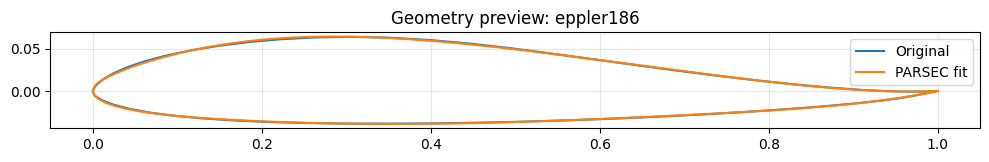

In [20]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 3 ── Fast multi-airfoil library build
# ══════════════════════════════════════════════════════════════════════════════
from pathlib import Path
import matplotlib.pyplot as plt
from airfoil import AirfoilGeometry
import parsec_fit

fit_parsec_to_dat = parsec_fit.fit_parsec_to_dat
fit_quality_report = parsec_fit.fit_quality_report

TRAIN_DIR = Path("/content/airfoils/train")
VAL_DIR   = Path("/content/airfoils/val")
TEST_DIR  = Path("/content/airfoils/test")

PARSEC_MAX_ERR_THRESHOLD = 4.5
PREVIEW_FIT_COUNT = 3   # only fit first few for preview now

def load_airfoil_library_fast(folder: Path, n_boundary: int = 1200, fit_now=False, fit_limit=0):
    lib = []
    skipped = []
    files = sorted(folder.glob("*.dat"))

    for i, f in enumerate(files):
        try:
            geom = AirfoilGeometry.from_dat(f, n_boundary=n_boundary)

            item = {
                "name": f.stem,
                "path": str(f),
                "geometry": geom,
                "parsec_params": None,
                "fit_report": None,
                "fit_mse": None,
                "use_for_optimization": False,
            }

            if fit_now and i < fit_limit:
                try:
                    params, mse = fit_parsec_to_dat(str(f), verbose=False)
                    report = fit_quality_report(str(f), params)

                    item["fit_mse"] = mse
                    item["fit_report"] = report

                    if report["max_error_pct"] <= PARSEC_MAX_ERR_THRESHOLD:
                        item["parsec_params"] = params
                        item["use_for_optimization"] = True

                except Exception as e_fit:
                    item["fit_report"] = {
                        "quality": "POOR",
                        "max_error_pct": 100.0,
                        "mean_error_pct": 100.0,
                        "error_message": str(e_fit),
                        "fitted_bx": geom.boundary[:, 0].tolist(),
                        "fitted_by": geom.boundary[:, 1].tolist(),
                    }

            lib.append(item)

        except Exception as e_geom:
            skipped.append((f.stem, str(e_geom)))

    return lib, skipped

TRAIN_AIRFOILS, TRAIN_SKIPPED = load_airfoil_library_fast(TRAIN_DIR, n_boundary=1200, fit_now=True, fit_limit=PREVIEW_FIT_COUNT)
VAL_AIRFOILS, VAL_SKIPPED     = load_airfoil_library_fast(VAL_DIR,   n_boundary=1200, fit_now=False)
TEST_AIRFOILS, TEST_SKIPPED   = load_airfoil_library_fast(TEST_DIR,  n_boundary=1200, fit_now=False)

print(f"Loaded {len(TRAIN_AIRFOILS)} training airfoils")
print(f"Loaded {len(VAL_AIRFOILS)} validation airfoils")
print(f"Loaded {len(TEST_AIRFOILS)} test airfoils")

if TRAIN_SKIPPED or VAL_SKIPPED or TEST_SKIPPED:
    print("\nSkipped files:")
    for name, err in TRAIN_SKIPPED + VAL_SKIPPED + TEST_SKIPPED:
        print(f"  {name}: {err}")

preview_items = [a for a in TRAIN_AIRFOILS if a["fit_report"] is not None]
if preview_items:
    ex = sorted(preview_items, key=lambda a: a["fit_report"]["max_error_pct"])[0]
    print("\nExample airfoil:", ex["name"])
    print("Fit quality:", ex["fit_report"]["quality"])
    print("Max error  :", ex["fit_report"]["max_error_pct"], "% chord")

    plt.figure(figsize=(10, 3.2))
    plt.plot(ex["geometry"].boundary[:, 0], ex["geometry"].boundary[:, 1], label="Original")
    plt.plot(ex["fit_report"]["fitted_bx"], ex["fit_report"]["fitted_by"], label="PARSEC fit")
    plt.gca().set_aspect("equal", adjustable="box")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.title(f"Geometry preview: {ex['name']}")
    plt.tight_layout()
    plt.show()

In [23]:
# %% [code]
# CELL 4 ─ choose stage
STAGE = 1  # 1=pilot, 2=research, 3=pilot+opt
ALPHA_DEG = 5.0
RE_PHYS = 1e5
XLIM = (-1.0, 2.0)
YLIM = (-1.0, 1.0)
if STAGE == 1:
    AOA_LIST = [ALPHA_DEG]
    RE_LIST = [RE_PHYS]
    N_INT, N_NEAR, N_WAKE = 3000, 1000, 600
    N_BOUNDARY = 2700
    N_AIRFOIL, N_INLET, N_OUTLET, N_TOP, N_BOT = 1200, 400, 400, 350, 350
    ADAM_STEPS, LBFGS_STEPS = 1500, 15
    ADAPTIVE_EVERY, ADAPTIVE_CAP = 300, 3000
    CANDIDATE_POOL = 20000
    GAUSS_PER_CENTER = 8
elif STAGE in (2,3):
    AOA_LIST = [-2, 0, 2, 4, 6, 8, 10, 12]
    RE_LIST = [5e4, 1e5, 2e5]
    N_INT, N_NEAR, N_WAKE = 12000, 2000, 2000
    N_AIRFOIL, N_INLET, N_OUTLET, N_TOP, N_BOT = 3000, 1500, 1500, 1000, 1000  # total boundary=8000
    ADAM_STEPS, LBFGS_STEPS = 30000, 100
    ADAPTIVE_EVERY, ADAPTIVE_CAP = 100, 10000
    CANDIDATE_POOL = 50000
    GAUSS_PER_CENTER = 16
else:
    raise ValueError('Unknown STAGE')
LR_ADAM, LR_MIN, LR_LAMBDA, WEIGHT_DECAY = 3e-4, 1e-5, 1e-4, 1e-5
PRINT_EVERY, SAVE_EVERY, VAL_EVERY = 100, 1000, 1000
OUT_DIR = 'research_checkpoints' if STAGE in (2,3) else 'pilot_checkpoints'
Path(OUT_DIR).mkdir(exist_ok=True)
print(f'Alpha = {ALPHA_DEG}°   Re = {RE_PHYS:.1e}')
print(f'Adam steps   = {ADAM_STEPS:,}   L-BFGS steps = {LBFGS_STEPS}')
print(f'Adaptive refresh every {ADAPTIVE_EVERY} steps; cap = {ADAPTIVE_CAP}')


Alpha = 5.0°   Re = 1.0e+05
Adam steps   = 1,500   L-BFGS steps = 15
Adaptive refresh every 300 steps; cap = 3000


In [24]:
# %% [code]
# CELL 5 ─ model
model = MLP(in_dim=5, out_dim=4, hidden_dim=64, num_hidden_layers=16, activation='silu', zero_init_last=True).to(device)
print('✓ Output layer zero-initialised (BC loss should start near 0)')
print(model)
print(f'\nTotal parameters : {sum(p.numel() for p in model.parameters()):,}')


✓ Output layer zero-initialised (BC loss should start near 0)
MLP(5→4, 64×16, act=silu, params=64,068)

Total parameters : 64,068


In [89]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 4 ── Stage configuration
# ══════════════════════════════════════════════════════════════════════════════
STAGE = 2   # 1 = pilot, 2 = research, 3 = optimize after training

AOA_LIST = [-2, 0, 2, 4, 6, 8, 10, 12]
RE_LIST  = [5e4, 1e5, 2e5]

XLIM = (-2.0, 1.0)
YLIM = (-1.0, 1.0)
NEAR_BAND = 0.003

if STAGE == 1:
    # Pilot
    N_INT = 3000
    N_NEAR = 1000
    N_WAKE = 600
    N_AIRFOIL = 800
    N_INLET = 400
    N_OUTLET = 400
    N_TOP = 400
    N_BOT = 400

    ADAPTIVE_EVERY = 300
    ADAPTIVE_CAP = 3000
    CANDIDATE_POOL = 10000
    GAUSS_PER_CENTER = 8
    RESIDUAL_PROBE_STRIDE = 4

    ADAM_STEPS = 1500
    LBFGS_STEPS = 15

    LR_ADAM = 3e-4
    LR_MIN = 1e-5
    LR_LAMBDA = 3e-4
    WEIGHT_DECAY = 1e-5

    PRINT_EVERY = 100
    SAVE_EVERY = 500
    VAL_EVERY = 500
    OUT_DIR = "pilot_checkpoints"

elif STAGE == 2:
    # Research-mode paper-scale
    # N_INT = 12000
    # N_NEAR = 2000
    # N_WAKE = 2000
    # N_AIRFOIL = 2000
    # N_INLET = 1500
    # N_OUTLET = 1500
    # N_TOP = 1500
    # N_BOT = 1500

    # ADAPTIVE_EVERY = 100
    # ADAPTIVE_CAP = 10000
    # CANDIDATE_POOL = 50000
    # GAUSS_PER_CENTER = 16
    # RESIDUAL_PROBE_STRIDE = 1

    # ADAM_STEPS = 30000
    # LBFGS_STEPS = 100
    # ADAM_STEPS = 5000
    # LBFGS_STEPS = 30

    N_INT = 3000
    N_NEAR = 600
    N_WAKE = 600
    N_AIRFOIL = 800
    N_INLET = 500
    N_OUTLET = 500
    N_TOP = 500
    N_BOT = 500

    ADAPTIVE_EVERY = 100
    ADAPTIVE_CAP = 2000
    CANDIDATE_POOL = 6000
    GAUSS_PER_CENTER = 6
    RESIDUAL_PROBE_STRIDE = 4

    ADAM_STEPS = 5000
    LBFGS_STEPS = 10
    LR_ADAM = 3e-4
    LR_MIN = 1e-5
    LR_LAMBDA = 1e-4
    WEIGHT_DECAY = 1e-5

    PRINT_EVERY = 100
    SAVE_EVERY = 1000
    VAL_EVERY = 1000
    OUT_DIR = "research_checkpoints"

elif STAGE == 3:
    # same as Stage 2 training, but optimization/export is mandatory afterwards
    N_INT = 12000
    N_NEAR = 2000
    N_WAKE = 2000
    N_AIRFOIL = 2000
    N_INLET = 1500
    N_OUTLET = 1500
    N_TOP = 1500
    N_BOT = 1500

    ADAPTIVE_EVERY = 100
    ADAPTIVE_CAP = 10000
    CANDIDATE_POOL = 50000
    GAUSS_PER_CENTER = 16
    RESIDUAL_PROBE_STRIDE = 1

    ADAM_STEPS = 30000
    LBFGS_STEPS = 100

    LR_ADAM = 3e-4
    LR_MIN = 1e-5
    LR_LAMBDA = 1e-4
    WEIGHT_DECAY = 1e-5

    PRINT_EVERY = 100
    SAVE_EVERY = 1000
    VAL_EVERY = 1000
    OUT_DIR = "research_opt_checkpoints"

else:
    raise ValueError("STAGE must be 1, 2, or 3")

from pathlib import Path
Path(OUT_DIR).mkdir(exist_ok=True)

TOTAL_BASE = N_INT + N_NEAR + N_WAKE + N_AIRFOIL + N_INLET + N_OUTLET + N_TOP + N_BOT
print("Stage:", STAGE)
print("Training airfoils:", len(TRAIN_AIRFOILS))
print("Validation airfoils:", len(VAL_AIRFOILS))
print("Test airfoils:", len(TEST_AIRFOILS))
print("AoA list:", AOA_LIST)
print("Re list :", RE_LIST)
print("Base points / refresh:", TOTAL_BASE)

Stage: 2
Training airfoils: 25
Validation airfoils: 2
Test airfoils: 3
AoA list: [-2, 0, 2, 4, 6, 8, 10, 12]
Re list : [50000.0, 100000.0, 200000.0]
Base points / refresh: 7000


In [90]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 5 ── Create model
# ══════════════════════════════════════════════════════════════════════════════
from network import MLP

model = MLP(
    in_dim=5,
    out_dim=4,
    hidden_dim=64,
    num_hidden_layers=16,
    activation="silu",
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nTotal parameters : {n_params:,}")

MLP(5→4, 64×16, act=silu, params=64,068)

Total parameters : 64,068


In [71]:
# ══════════════════════════════════════════════════════════════════════════════
# PATCH ── add train_multi_airfoil using existing single-airfoil train(...)
# ══════════════════════════════════════════════════════════════════════════════
import math
import random
from pathlib import Path
import train_loop

# get the existing single-airfoil trainer
_single_train = train_loop.train

def train_multi_airfoil(
    model,
    train_airfoils,
    val_airfoils,
    aoa_list,
    re_list,
    xlim,
    ylim,
    N_int,
    N_near,
    N_airfoil,
    N_inlet,
    N_outlet,
    N_top,
    N_bot,
    N_wake,
    near_band,
    adam_steps,
    lr_adam,
    lr_min,
    lr_lambda,
    weight_decay,
    refresh_every,
    adaptive_every,
    adaptive_cap,
    candidate_pool,
    gauss_per_center,
    residual_probe_stride,
    lbfgs_steps,
    print_every,
    save_every,
    val_every,
    out_dir,
    device,
    seed=42,
):
    random.seed(seed)

    Path(out_dir).mkdir(exist_ok=True, parents=True)

    # how many chunks to split the full training into
    # each chunk trains on one selected airfoil + one selected (AoA, Re)
    block_steps = min(500, adam_steps)   # safe chunk size
    n_blocks = max(1, math.ceil(adam_steps / block_steps))

    history = []
    adaptive_weights = None

    # build a deterministic schedule over airfoils/conditions
    conditions = [(a, r) for a in aoa_list for r in re_list]
    if len(conditions) == 0:
        raise ValueError("aoa_list and re_list must not be empty")
    if len(train_airfoils) == 0:
        raise ValueError("train_airfoils is empty")

    print(f"train_multi_airfoil: {len(train_airfoils)} airfoils, {len(conditions)} conditions, {n_blocks} blocks")

    for block in range(n_blocks):
        airfoil_item = train_airfoils[block % len(train_airfoils)]
        alpha_deg, Re_phys = conditions[block % len(conditions)]

        this_steps = min(block_steps, adam_steps - block * block_steps)
        if this_steps <= 0:
            break

        block_dir = Path(out_dir) / f"block_{block:03d}_{airfoil_item['name']}_a{alpha_deg}_Re{int(Re_phys)}"
        block_dir.mkdir(exist_ok=True, parents=True)

        print("\n" + "=" * 70)
        print(f"BLOCK {block+1}/{n_blocks}")
        print(f"  Airfoil : {airfoil_item['name']}")
        print(f"  AoA     : {alpha_deg} deg")
        print(f"  Re      : {Re_phys:.3e}")
        print(f"  Steps   : {this_steps}")
        print("=" * 70)

        model, adaptive_weights = _single_train(
            model=model,
            geometry=airfoil_item["geometry"],
            alpha_deg=float(alpha_deg),
            Re_phys=float(Re_phys),
            xlim=xlim,
            ylim=ylim,
            N_int=N_int,
            N_near=N_near,
            N_airfoil=N_airfoil,
            N_inlet=N_inlet,
            N_outlet=N_outlet,
            N_top=N_top,
            N_bot=N_bot,
            N_wake=N_wake,
            near_band=near_band,
            adam_steps=this_steps,
            lr_adam=lr_adam,
            lr_min=lr_min,
            lr_lambda=lr_lambda,
            weight_decay=weight_decay,
            refresh_every=refresh_every,
            adaptive_every=adaptive_every,
            adaptive_cap=adaptive_cap,
            lbfgs_steps=0,   # do L-BFGS only once at the very end
            lr_lbfgs=1.0,
            print_every=print_every,
            save_every=save_every,
            out_dir=str(block_dir),
            device=device,
            seed=seed + block,
            candidate_pool=candidate_pool,
            gauss_per_center=gauss_per_center,
            residual_probe_stride=residual_probe_stride,
        )

        history.append({
            "block": block,
            "airfoil": airfoil_item["name"],
            "alpha_deg": float(alpha_deg),
            "Re": float(Re_phys),
            "steps": int(this_steps),
        })

    # final single L-BFGS polish on one representative training case
    if lbfgs_steps > 0:
        final_airfoil = train_airfoils[0]
        final_alpha, final_Re = conditions[0]

        print("\n" + "=" * 70)
        print("FINAL L-BFGS POLISH")
        print(f"  Airfoil : {final_airfoil['name']}")
        print(f"  AoA     : {final_alpha} deg")
        print(f"  Re      : {final_Re:.3e}")
        print(f"  Steps   : {lbfgs_steps}")
        print("=" * 70)

        final_dir = Path(out_dir) / "final_lbfgs"
        final_dir.mkdir(exist_ok=True, parents=True)

        model, adaptive_weights = _single_train(
            model=model,
            geometry=final_airfoil["geometry"],
            alpha_deg=float(final_alpha),
            Re_phys=float(final_Re),
            xlim=xlim,
            ylim=ylim,
            N_int=N_int,
            N_near=N_near,
            N_airfoil=N_airfoil,
            N_inlet=N_inlet,
            N_outlet=N_outlet,
            N_top=N_top,
            N_bot=N_bot,
            N_wake=N_wake,
            near_band=near_band,
            adam_steps=0,
            lr_adam=lr_adam,
            lr_min=lr_min,
            lr_lambda=lr_lambda,
            weight_decay=weight_decay,
            refresh_every=refresh_every,
            adaptive_every=adaptive_every,
            adaptive_cap=adaptive_cap,
            lbfgs_steps=lbfgs_steps,
            lr_lbfgs=1.0,
            print_every=print_every,
            save_every=save_every,
            out_dir=str(final_dir),
            device=device,
            seed=seed,
            candidate_pool=candidate_pool,
            gauss_per_center=gauss_per_center,
            residual_probe_stride=residual_probe_stride,
        )

    return model, adaptive_weights, history

# patch module so `from train_loop import train_multi_airfoil` also works later
train_loop.train_multi_airfoil = train_multi_airfoil

print("Patched train_loop.train_multi_airfoil")

Patched train_loop.train_multi_airfoil


In [34]:
Xtest = torch.randn(8, 5, device=device, requires_grad=True)
Ytest = model(Xtest)
u = Ytest[:, 0:1]

print(torch.autograd.grad(u, Xtest, torch.ones_like(u), create_graph=True)[0].shape)

torch.Size([8, 5])


In [40]:
Xtest = torch.randn(8, 5, device=device, requires_grad=True)
Ytest = model(Xtest)

print("Ytest.requires_grad =", Ytest.requires_grad)
print("Ytest.shape =", Ytest.shape)

names = ["u", "v", "p", "nu_t"]
for i, name in enumerate(names):
    y = Ytest[:, i:i+1]
    g = torch.autograd.grad(
        y,
        Xtest,
        grad_outputs=torch.ones_like(y),
        create_graph=True,
        retain_graph=True,
        allow_unused=True,
    )[0]
    print(name, "grad is None?", g is None)

Ytest.requires_grad = True
Ytest.shape = torch.Size([8, 4])
u grad is None? False
v grad is None? False
p grad is None? False
nu_t grad is None? False


In [55]:
import importlib
import residuals
import train_loop
import losses

importlib.reload(residuals)
importlib.reload(losses)
importlib.reload(train_loop)

<module 'train_loop' from '/content/train_loop.py'>

In [56]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 6 ── Multi-airfoil training
# ══════════════════════════════════════════════════════════════════════════════
import train_loop

print("=" * 62)
if STAGE == 1:
    print(" STAGE 1: Pilot")
elif STAGE == 2:
    print(" STAGE 2: Research")
else:
    print(" STAGE 3: Research + Final Optimization")
print(f" AdamW steps = {ADAM_STEPS}")
print(f" L-BFGS steps = {LBFGS_STEPS}")
print(f" Adaptive every = {ADAPTIVE_EVERY}")
print(f" Adaptive cap   = {ADAPTIVE_CAP}")
print("=" * 62)

model, adaptive_weights, history = train_loop.train_multi_airfoil(
    model=model,
    train_airfoils=TRAIN_AIRFOILS,
    val_airfoils=VAL_AIRFOILS,
    aoa_list=AOA_LIST,
    re_list=RE_LIST,
    xlim=XLIM,
    ylim=YLIM,
    N_int=N_INT,
    N_near=N_NEAR,
    N_airfoil=N_AIRFOIL,
    N_inlet=N_INLET,
    N_outlet=N_OUTLET,
    N_top=N_TOP,
    N_bot=N_BOT,
    N_wake=N_WAKE,
    near_band=NEAR_BAND,
    adam_steps=ADAM_STEPS,
    lr_adam=LR_ADAM,
    lr_min=LR_MIN,
    lr_lambda=LR_LAMBDA,
    weight_decay=WEIGHT_DECAY,
    refresh_every=ADAPTIVE_EVERY,
    adaptive_every=ADAPTIVE_EVERY,
    adaptive_cap=ADAPTIVE_CAP,
    candidate_pool=CANDIDATE_POOL,
    gauss_per_center=GAUSS_PER_CENTER,
    residual_probe_stride=RESIDUAL_PROBE_STRIDE,
    lbfgs_steps=LBFGS_STEPS,
    print_every=PRINT_EVERY,
    save_every=SAVE_EVERY,
    val_every=VAL_EVERY,
    out_dir=OUT_DIR,
    device=device,
    seed=42,
)

print("Training finished.")
print("Final adaptive weights:", adaptive_weights.all_weights())
print("History blocks:", len(history))

 STAGE 1: Pilot
 AdamW steps = 1500
 L-BFGS steps = 15
 Adaptive every = 300
 Adaptive cap   = 3000
train_multi_airfoil: 25 airfoils, 24 conditions, 3 blocks

BLOCK 1/3
  Airfoil : eppler186
  AoA     : -2 deg
  Re      : 5.000e+04
  Steps   : 500
  step   100  loss=7.4130e-03  pde=7.9013e-03  wall=2.0174e-03  lr=2.72e-04  λwall=0.68  λpde=0.68
  step   200  loss=1.0254e-03  pde=1.2365e-03  wall=1.1058e-04  lr=2.00e-04  λwall=0.68  λpde=0.68
  step   300  loss=4.7059e-04  pde=5.4266e-04  wall=2.0949e-05  lr=1.10e-04  λwall=0.68  λpde=0.67
  step   400  loss=3.5368e-04  pde=3.9128e-04  wall=1.0384e-05  lr=3.77e-05  λwall=0.68  λpde=0.67
  step   500  loss=3.2806e-04  pde=3.5837e-04  wall=8.5770e-06  lr=1.00e-05  λwall=0.68  λpde=0.67

BLOCK 2/3
  Airfoil : mh60
  AoA     : -2 deg
  Re      : 1.000e+05
  Steps   : 500
  step   100  loss=3.5896e-04  pde=4.1784e-04  wall=1.0863e-05  lr=2.72e-04  λwall=0.69  λpde=0.68
  step   200  loss=1.7974e-04  pde=1.8361e-04  wall=3.1400e-06  lr=2.00e-

### **stage 02**

In [82]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [91]:
# PATCH ── improved train_multi_airfoil scheduler
import math
import random
from pathlib import Path
import train_loop

_single_train = train_loop.train

def train_multi_airfoil(
    model,
    train_airfoils,
    val_airfoils,
    aoa_list,
    re_list,
    xlim,
    ylim,
    N_int,
    N_near,
    N_airfoil,
    N_inlet,
    N_outlet,
    N_top,
    N_bot,
    N_wake,
    near_band,
    adam_steps,
    lr_adam,
    lr_min,
    lr_lambda,
    weight_decay,
    refresh_every,
    adaptive_every,
    adaptive_cap,
    candidate_pool,
    gauss_per_center,
    residual_probe_stride,
    lbfgs_steps,
    print_every,
    save_every,
    val_every,
    out_dir,
    device,
    seed=42,
):
    random.seed(seed)
    Path(out_dir).mkdir(exist_ok=True, parents=True)

    block_steps = 250 if adam_steps >= 10000 else min(500, adam_steps)
    n_blocks = max(1, math.ceil(adam_steps / block_steps))

    # build all combinations and shuffle
    combos = []
    for a in train_airfoils:
        for aoa in aoa_list:
            for re in re_list:
                combos.append((a, aoa, re))

    random.shuffle(combos)

    history = []
    adaptive_weights = None

    print(f"train_multi_airfoil: {len(train_airfoils)} airfoils, {len(aoa_list)*len(re_list)} conditions, {n_blocks} blocks")

    for block in range(n_blocks):
        airfoil_item, alpha_deg, Re_phys = combos[block % len(combos)]
        this_steps = min(block_steps, adam_steps - block * block_steps)
        if this_steps <= 0:
            break

        block_dir = Path(out_dir) / f"block_{block:03d}_{airfoil_item['name']}_a{alpha_deg}_Re{int(Re_phys)}"
        block_dir.mkdir(exist_ok=True, parents=True)

        print("\n" + "=" * 70)
        print(f"BLOCK {block+1}/{n_blocks}")
        print(f"  Airfoil : {airfoil_item['name']}")
        print(f"  AoA     : {alpha_deg} deg")
        print(f"  Re      : {Re_phys:.3e}")
        print(f"  Steps   : {this_steps}")
        print("=" * 70)

        model, adaptive_weights = _single_train(
            model=model,
            geometry=airfoil_item["geometry"],
            alpha_deg=float(alpha_deg),
            Re_phys=float(Re_phys),
            xlim=xlim,
            ylim=ylim,
            N_int=N_int,
            N_near=N_near,
            N_airfoil=N_airfoil,
            N_inlet=N_inlet,
            N_outlet=N_outlet,
            N_top=N_top,
            N_bot=N_bot,
            N_wake=N_wake,
            near_band=near_band,
            adam_steps=this_steps,
            lr_adam=lr_adam,
            lr_min=lr_min,
            lr_lambda=lr_lambda,
            weight_decay=weight_decay,
            refresh_every=refresh_every,
            adaptive_every=adaptive_every,
            adaptive_cap=adaptive_cap,
            lbfgs_steps=0,
            lr_lbfgs=1.0,
            print_every=print_every,
            save_every=save_every,
            out_dir=str(block_dir),
            device=device,
            seed=seed + block,
            candidate_pool=candidate_pool,
            gauss_per_center=gauss_per_center,
            residual_probe_stride=residual_probe_stride,
        )

        history.append({
            "block": block,
            "airfoil": airfoil_item["name"],
            "alpha_deg": float(alpha_deg),
            "Re": float(Re_phys),
            "steps": int(this_steps),
        })

    if lbfgs_steps > 0:
        final_airfoil, final_alpha, final_Re = combos[0]

        print("\n" + "=" * 70)
        print("FINAL L-BFGS POLISH")
        print(f"  Airfoil : {final_airfoil['name']}")
        print(f"  AoA     : {final_alpha} deg")
        print(f"  Re      : {final_Re:.3e}")
        print(f"  Steps   : {lbfgs_steps}")
        print("=" * 70)

        final_dir = Path(out_dir) / "final_lbfgs"
        final_dir.mkdir(exist_ok=True, parents=True)

        model, adaptive_weights = _single_train(
            model=model,
            geometry=final_airfoil["geometry"],
            alpha_deg=float(final_alpha),
            Re_phys=float(final_Re),
            xlim=xlim,
            ylim=ylim,
            N_int=N_int,
            N_near=N_near,
            N_airfoil=N_AIRFOIL,
            N_inlet=N_INLET,
            N_outlet=N_OUTLET,
            N_top=N_TOP,
            N_bot=N_BOT,
            N_wake=N_WAKE,
            near_band=near_band,
            adam_steps=0,
            lr_adam=lr_adam,
            lr_min=lr_min,
            lr_lambda=lr_lambda,
            weight_decay=weight_decay,
            refresh_every=refresh_every,
            adaptive_every=adaptive_every,
            adaptive_cap=adaptive_cap,
            lbfgs_steps=lbfgs_steps,
            lr_lbfgs=1.0,
            print_every=print_every,
            save_every=save_every,
            out_dir=str(final_dir),
            device=device,
            seed=seed,
            candidate_pool=candidate_pool,
            gauss_per_center=gauss_per_center,
            residual_probe_stride=residual_probe_stride,
        )

    return model, adaptive_weights, history

train_loop.train_multi_airfoil = train_multi_airfoil
print("Patched improved train_multi_airfoil")

Patched improved train_multi_airfoil


In [92]:
# PATCH ─ chunked residual scoring to reduce VRAM
import numpy as np
import torch
import train_loop
from residuals import pde_residuals_rans_sa

def _residual_scores_chunked(model, geometry, alpha_deg, Re_phys, xlim, ylim,
                             candidate_pool, device, residual_probe_stride=1,
                             chunk_size=2000):
    from sampling import _sample_outside_exact, _sample_rect_sobol

    cand = _sample_outside_exact(
        candidate_pool,
        lambda n: _sample_rect_sobol(n, xlim, ylim, seed=123),
        geometry=geometry,
        alpha_deg=alpha_deg,
        Re_phys=Re_phys,
    )

    Xcand = torch.tensor(cand, dtype=torch.float32, device=device)
    probe = Xcand[::max(1, int(residual_probe_stride))]

    pts_xy = []
    scores = []

    for i in range(0, len(probe), chunk_size):
        chunk = probe[i:i+chunk_size].clone().detach().requires_grad_(True)

        with torch.enable_grad():
            Y = model(chunk)
            res = pde_residuals_rans_sa(Y, chunk)
            score = (
                res["continuity"].abs()
                + res["mom_x"].abs()
                + res["mom_y"].abs()
                + res["sa"].abs()
            ).detach().cpu().numpy().reshape(-1)

        pts_xy.append(chunk[:, :2].detach().cpu().numpy())
        scores.append(score)

        del chunk, Y, res
        torch.cuda.empty_cache()

    return np.vstack(pts_xy), np.concatenate(scores)

train_loop._residual_scores = _residual_scores_chunked
print("Patched train_loop._residual_scores with chunked version")

Patched train_loop._residual_scores with chunked version


In [93]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [94]:
import gc
import torch

gc.collect()
torch.cuda.empty_cache()
print(torch.cuda.memory_summary(device=None, abbreviated=True))

|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 5            |        cudaMalloc retries: 8         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |  18815 KiB |  39876 MiB |  15321 GiB |  15321 GiB |
|---------------------------------------------------------------------------|
| Active memory         |  18815 KiB |  39876 MiB |  15321 GiB |  15321 GiB |
|---------------------------------------------------------------------------|
| Requested memory      |  18751 KiB |  39220 MiB |  14718 GiB |  14718 GiB |
|---------------------------------------------------------------

In [95]:
# PATCH ─ chunked PDE residual evaluation inside train_loop.train
import torch
import train_loop
from losses import total_loss
from residuals import pde_residuals_rans_sa

# keep old helpers from train_loop
_build_bc_losses = train_loop._build_bc_losses
_init_optimizer_scheduler = train_loop._init_optimizer_scheduler
_build_cloud = train_loop._build_cloud
_init_loss_weights = train_loop._init_loss_weights

def _merge_residual_chunks(res_list):
    keys = res_list[0].keys()
    merged = {}
    for k in keys:
        merged[k] = torch.cat([r[k] for r in res_list], dim=0)
    return merged

def _pde_residuals_chunked(model, Xint, chunk_size=1500):
    chunks = []
    for i in range(0, Xint.shape[0], chunk_size):
        Xi = Xint[i:i+chunk_size].clone().detach().requires_grad_(True)
        Yi = model(Xi)
        ri = pde_residuals_rans_sa(Yi, Xi)
        chunks.append(ri)
    return _merge_residual_chunks(chunks)

_old_train = train_loop.train

def train_chunked(
    model,
    geometry,
    alpha_deg,
    Re_phys,
    xlim,
    ylim,
    N_int,
    N_near,
    N_airfoil,
    N_inlet,
    N_outlet,
    N_top,
    N_bot,
    N_wake,
    near_band,
    adam_steps,
    lr_adam,
    lr_min,
    lr_lambda,
    weight_decay,
    refresh_every,
    adaptive_every,
    adaptive_cap,
    lbfgs_steps,
    lr_lbfgs=1.0,
    print_every=100,
    save_every=500,
    out_dir="outputs",
    device="cuda",
    seed=42,
    candidate_pool=6000,
    gauss_per_center=6,
    residual_probe_stride=4,
    AOA_LIST=None,
    RE_LIST=None,
    callback=None,
    pde_chunk_size=1500,
):
    # initialize same way as original train()
    model = model.to(device).train()
    optimizer, scheduler = _init_optimizer_scheduler(
        model=model,
        lr_adam=lr_adam,
        lr_min=lr_min,
        adam_steps=adam_steps,
        weight_decay=weight_decay,
    )
    loss_weights = _init_loss_weights(model, lr_lambda=lr_lambda, device=device)

    cloud_t, adaptive = _build_cloud(
        geometry=geometry,
        alpha_deg=alpha_deg,
        Re_phys=Re_phys,
        xlim=xlim,
        ylim=ylim,
        N_int=N_int,
        N_near=N_near,
        N_airfoil=N_airfoil,
        N_inlet=N_inlet,
        N_outlet=N_outlet,
        N_top=N_top,
        N_bot=N_bot,
        N_wake=N_wake,
        near_band=near_band,
        device=device,
        seed=seed,
        adaptive_cap=adaptive_cap,
        candidate_pool=candidate_pool,
        gauss_per_center=gauss_per_center,
        residual_probe_stride=residual_probe_stride,
    )

    # set normalization once if available
    if hasattr(model, "set_normalization"):
        with torch.no_grad():
            x_norm = torch.cat(
                [cloud_t["interior"], cloud_t["near"], cloud_t["wake"]], dim=0
            ).detach().cpu().numpy()
        model.set_normalization(x_norm)

    for step in range(1, adam_steps + 1):
        optimizer.zero_grad(set_to_none=True)

        Xint = torch.cat(
            [cloud_t["interior"], cloud_t["near"], cloud_t["wake"], cloud_t["adaptive"]],
            dim=0
        )

        residuals = _pde_residuals_chunked(model, Xint, chunk_size=pde_chunk_size)
        bc = _build_bc_losses(model, cloud_t, alpha_deg, Re_phys)
        loss, parts = total_loss(model, residuals, bc, loss_weights)

        loss.backward()
        optimizer.step()
        scheduler.step()
        loss_weights.step(parts)

        if step % adaptive_every == 0:
            cand_xy, score = train_loop._residual_scores(
                model, geometry, alpha_deg, Re_phys, xlim, ylim,
                adaptive.candidate_pool, device=device,
                residual_probe_stride=adaptive.residual_probe_stride
            )
            adaptive.update(cand_xy, score)
            cloud_t, adaptive = _build_cloud(
                geometry=geometry,
                alpha_deg=alpha_deg,
                Re_phys=Re_phys,
                xlim=xlim,
                ylim=ylim,
                N_int=N_int,
                N_near=N_near,
                N_airfoil=N_airfoil,
                N_inlet=N_inlet,
                N_outlet=N_outlet,
                N_top=N_top,
                N_bot=N_bot,
                N_wake=N_wake,
                near_band=near_band,
                device=device,
                seed=seed + step,
                adaptive_cap=adaptive_cap,
                candidate_pool=candidate_pool,
                gauss_per_center=gauss_per_center,
                residual_probe_stride=residual_probe_stride,
                adaptive_sampler=adaptive,
            )

        if step % print_every == 0:
            lr_now = scheduler.get_last_lr()[0]
            w = loss_weights.all_weights()
            print(
                f"  step {step:5d}  loss={loss.item():.4e}  "
                f"pde={parts['pde'].item():.4e}  wall={parts['wall'].item():.4e}  "
                f"lr={lr_now:.2e}  λwall={w['wall']:.2f}  λpde={w['pde']:.2f}"
            )

        torch.cuda.empty_cache()

    # final LBFGS: skip if too memory-heavy for now, or leave to original if needed
    if lbfgs_steps > 0:
        print("Skipping L-BFGS in chunked patch version for memory safety.")
    return model, loss_weights

train_loop.train = train_chunked
print("Patched train_loop.train with chunked PDE residual evaluation")

AttributeError: module 'train_loop' has no attribute '_init_optimizer_scheduler'

In [88]:
# ══════════════════════════════════════════════════════════════════════════════
# PATCH ─ chunked forward pass for the current model
# ══════════════════════════════════════════════════════════════════════════════
import types
import torch

def attach_chunked_forward(model, chunk_size=1500):
    # keep original forward
    if not hasattr(model, "_forward_full"):
        model._forward_full = model.forward

    def forward_chunked(self, x):
        # small tensors can go through normally
        if x.shape[0] <= chunk_size:
            return self._forward_full(x)

        outs = []
        for i in range(0, x.shape[0], chunk_size):
            xi = x[i:i + chunk_size]
            yi = self._forward_full(xi)
            outs.append(yi)
        return torch.cat(outs, dim=0)

    model.forward = types.MethodType(forward_chunked, model)
    return model

model = attach_chunked_forward(model, chunk_size=1500)
print("Attached chunked forward pass to model.")

Attached chunked forward pass to model.


In [96]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 6 ── Multi-airfoil training
# ══════════════════════════════════════════════════════════════════════════════
import train_loop

print("=" * 62)
if STAGE == 1:
    print(" STAGE 1: Pilot")
elif STAGE == 2:
    print(" STAGE 2: Research")
else:
    print(" STAGE 3: Research + Final Optimization")
print(f" AdamW steps = {ADAM_STEPS}")
print(f" L-BFGS steps = {LBFGS_STEPS}")
print(f" Adaptive every = {ADAPTIVE_EVERY}")
print(f" Adaptive cap   = {ADAPTIVE_CAP}")
print("=" * 62)

model, adaptive_weights, history = train_loop.train_multi_airfoil(
    model=model,
    train_airfoils=TRAIN_AIRFOILS,
    val_airfoils=VAL_AIRFOILS,
    aoa_list=AOA_LIST,
    re_list=RE_LIST,
    xlim=XLIM,
    ylim=YLIM,
    N_int=N_INT,
    N_near=N_NEAR,
    N_airfoil=N_AIRFOIL,
    N_inlet=N_INLET,
    N_outlet=N_OUTLET,
    N_top=N_TOP,
    N_bot=N_BOT,
    N_wake=N_WAKE,
    near_band=NEAR_BAND,
    adam_steps=ADAM_STEPS,
    lr_adam=LR_ADAM,
    lr_min=LR_MIN,
    lr_lambda=LR_LAMBDA,
    weight_decay=WEIGHT_DECAY,
    refresh_every=ADAPTIVE_EVERY,
    adaptive_every=ADAPTIVE_EVERY,
    adaptive_cap=ADAPTIVE_CAP,
    candidate_pool=CANDIDATE_POOL,
    gauss_per_center=GAUSS_PER_CENTER,
    residual_probe_stride=RESIDUAL_PROBE_STRIDE,
    lbfgs_steps=LBFGS_STEPS,
    print_every=PRINT_EVERY,
    save_every=SAVE_EVERY,
    val_every=VAL_EVERY,
    out_dir=OUT_DIR,
    device=device,
    seed=42,
)

print("Training finished.")
print("Final adaptive weights:", adaptive_weights.all_weights())
print("History blocks:", len(history))

 STAGE 2: Research
 AdamW steps = 5000
 L-BFGS steps = 10
 Adaptive every = 100
 Adaptive cap   = 2000
train_multi_airfoil: 25 airfoils, 24 conditions, 10 blocks

BLOCK 1/10
  Airfoil : s809
  AoA     : 2 deg
  Re      : 2.000e+05
  Steps   : 500
  step   100  loss=7.4508e-03  pde=7.3933e-03  wall=2.6127e-03  lr=2.72e-04  λwall=0.69  λpde=0.69
  step   200  loss=1.3683e-03  pde=1.5302e-03  wall=2.1081e-04  lr=2.00e-04  λwall=0.69  λpde=0.69
  step   300  loss=6.2768e-04  pde=6.5309e-04  wall=6.7698e-05  lr=1.10e-04  λwall=0.69  λpde=0.69
  step   400  loss=4.6029e-04  pde=4.6017e-04  wall=3.9404e-05  lr=3.77e-05  λwall=0.69  λpde=0.69
  step   500  loss=4.2367e-04  pde=4.1917e-04  wall=3.3637e-05  lr=1.00e-05  λwall=0.69  λpde=0.69

BLOCK 2/10
  Airfoil : sd7034
  AoA     : 12 deg
  Re      : 2.000e+05
  Steps   : 500
  step   100  loss=2.7762e-03  pde=1.1856e-04  wall=5.3076e-05  lr=2.72e-04  λwall=0.69  λpde=0.69
  step   200  loss=1.5167e-03  pde=4.6795e-05  wall=5.6962e-06  lr=2.00

NameError: name 'N_neAR' is not defined

In [97]:
#clear memory before stage 3
import gc, torch
gc.collect()
torch.cuda.empty_cache()
model.eval()


MLP(5→4, 64×16, act=silu, params=64,068)

In [98]:
OPT_ITERS = 30
OPT_MODE = "lbfgs"
OPT_ALPHA = 5.0
OPT_RE = 1e5

In [99]:
import gc, torch
gc.collect()
torch.cuda.empty_cache()
model.eval()

MLP(5→4, 64×16, act=silu, params=64,068)

### **stage 3**

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 8 ── Stage 3: Final optimized airfoil export
# ══════════════════════════════════════════════════════════════════════════════
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
import gc
import torch

from airfoil import AirfoilGeometry
from train_loop import optimize_shape

# --------------------------------------------------------------------------
# 0. Memory safety
# --------------------------------------------------------------------------
gc.collect()
torch.cuda.empty_cache()
model.eval()

# --------------------------------------------------------------------------
# 1. Choose ONE airfoil to optimize
# --------------------------------------------------------------------------
# Change this to any airfoil in TRAIN_AIRFOILS / VAL_AIRFOILS / TEST_AIRFOILS
TARGET_AIRFOIL_NAME = "s809"

# Search in all loaded libraries
ALL_AIRFOILS = TRAIN_AIRFOILS + VAL_AIRFOILS + TEST_AIRFOILS
match = [a for a in ALL_AIRFOILS if a["name"] == TARGET_AIRFOIL_NAME]

if not match:
    raise ValueError(f"Airfoil '{TARGET_AIRFOIL_NAME}' not found in loaded libraries.")

target = match[0]

# --------------------------------------------------------------------------
# 2. Make sure it has usable PARSEC parameters
# --------------------------------------------------------------------------
if target["parsec_params"] is None:
    raise ValueError(
        f"Airfoil '{TARGET_AIRFOIL_NAME}' does not currently have an acceptable PARSEC fit, "
        f"so it cannot be optimized with PARSEC-based Stage 3 yet."
    )

# --------------------------------------------------------------------------
# 3. Optimization settings (small + safe)
# --------------------------------------------------------------------------
OPT_MODE = "lbfgs"     # safer than PPO for now
OPT_ITERS = 30
OPT_ALPHA = 5.0
OPT_RE = 1e5

# smaller evaluation domain for optimization
OPT_XLIM = XLIM
OPT_YLIM = YLIM

# smaller point counts than training
OPT_N_INT = 1500
OPT_N_NEAR = 300
OPT_N_WAKE = 300
OPT_N_AIRFOIL = 400
OPT_N_INLET = 250
OPT_N_OUTLET = 250
OPT_N_TOP = 250
OPT_N_BOT = 250

# --------------------------------------------------------------------------
# 4. Output folder
# --------------------------------------------------------------------------
OPT_OUT = Path("optimized_results")
OPT_OUT.mkdir(exist_ok=True)

# --------------------------------------------------------------------------
# 5. Run shape optimization
# --------------------------------------------------------------------------
print("=" * 70)
print("STAGE 3 ─ FINAL AIRFOIL OPTIMIZATION")
print(f"Target airfoil : {target['name']}")
print(f"Optimization   : {OPT_MODE}")
print(f"Iterations     : {OPT_ITERS}")
print(f"AoA            : {OPT_ALPHA} deg")
print(f"Re             : {OPT_RE:.3e}")
print("=" * 70)

best_params, best_info = optimize_shape(
    model=model,
    init_parsec=target["parsec_params"],
    mode=OPT_MODE,
    iters=OPT_ITERS,
    alpha_deg=OPT_ALPHA,
    Re_phys=OPT_RE,
    xlim=OPT_XLIM,
    ylim=OPT_YLIM,
    N_int=OPT_N_INT,
    N_near=OPT_N_NEAR,
    N_airfoil=OPT_N_AIRFOIL,
    N_inlet=OPT_N_INLET,
    N_outlet=OPT_N_OUTLET,
    N_top=OPT_N_TOP,
    N_bot=OPT_N_BOT,
    N_wake=OPT_N_WAKE,
    device=device,
)

print("\nOptimization finished.")
print("Best info:", best_info)

# --------------------------------------------------------------------------
# 6. Build optimized airfoil geometry
# --------------------------------------------------------------------------
OPT_AIRFOIL = AirfoilGeometry.from_parsec(best_params, n_boundary=1200)

# fitted PARSEC airfoil from original fitted params
FIT_AIRFOIL = AirfoilGeometry.from_parsec(target["parsec_params"], n_boundary=1200)

# original airfoil geometry
BASE_AIRFOIL = target["geometry"]

# --------------------------------------------------------------------------
# 7. Save optimized results
# --------------------------------------------------------------------------
# save optimized PARSEC parameters
with open(OPT_OUT / "optimized_parsec.json", "w") as f:
    json.dump(
        {
            "airfoil_name": target["name"],
            "alpha_deg": OPT_ALPHA,
            "Re": OPT_RE,
            "optimization_mode": OPT_MODE,
            "iterations": OPT_ITERS,
            "best_info": best_info,
            "optimized_parsec": np.asarray(best_params, dtype=float).tolist(),
        },
        f,
        indent=2,
    )

# save optimized airfoil boundary
np.savetxt(
    OPT_OUT / "optimized_airfoil_boundary.csv",
    OPT_AIRFOIL.boundary,
    delimiter=",",
    header="x,y",
    comments=""
)

# save fitted PARSEC boundary too
np.savetxt(
    OPT_OUT / "fitted_parsec_boundary.csv",
    FIT_AIRFOIL.boundary,
    delimiter=",",
    header="x,y",
    comments=""
)

# save original airfoil boundary
np.savetxt(
    OPT_OUT / "original_airfoil_boundary.csv",
    BASE_AIRFOIL.boundary,
    delimiter=",",
    header="x,y",
    comments=""
)

# --------------------------------------------------------------------------
# 8. Plot comparison
# --------------------------------------------------------------------------
plt.figure(figsize=(10, 3.8))
plt.plot(BASE_AIRFOIL.boundary[:, 0], BASE_AIRFOIL.boundary[:, 1], lw=2, label="Original airfoil")
plt.plot(FIT_AIRFOIL.boundary[:, 0], FIT_AIRFOIL.boundary[:, 1], lw=2, label="Fitted PARSEC")
plt.plot(OPT_AIRFOIL.boundary[:, 0], OPT_AIRFOIL.boundary[:, 1], lw=2, label="Optimized airfoil")

plt.gca().set_aspect("equal", adjustable="box")
plt.grid(True, alpha=0.3)
plt.legend()
plt.title(f"Original vs Fitted vs Optimized: {target['name']}")
plt.xlabel("x/c")
plt.ylabel("y/c")
plt.tight_layout()
plt.savefig(OPT_OUT / "optimized_airfoil_comparison.png", dpi=180)
plt.show()

print("\nSaved files:")
print(" - optimized_results/optimized_parsec.json")
print(" - optimized_results/optimized_airfoil_boundary.csv")
print(" - optimized_results/fitted_parsec_boundary.csv")
print(" - optimized_results/original_airfoil_boundary.csv")
print(" - optimized_results/optimized_airfoil_comparison.png")